# Research Paper Answer Bot

**Analytics Vidhya GenAI Pinnacle Plus Capstone**

This editable notebook consolidates the project source code, reproducibility steps, and recorded evaluation results. Run it from the project root: `C:/Users/mugee/Downloads/AV_Capstone/capstone`.

The notebook intentionally preserves the original project modules as separate cells so that each stage remains easy to inspect, modify, and execute.

## Project At A Glance

- Knowledge base: **9 research papers**, **319 pages**, and **1291 page-aware chunks**
- Chunking: 1000 characters with 150-character overlap
- Final pipeline: **BGE-M3 -> ChromaDB dense top-10 -> BGE reranker -> top-3 -> Gemini 2.5 Flash**
- Retrieval evaluation: 10 questions using Hit@1, Hit@3, and MRR
- Stretch goals: Conversational RAG, Corrective RAG (CRAG) with Tavily, and Streamlit chat UI

## Environment Setup

Install the libraries below once. Set `GOOGLE_API_KEY` before generating RAG answers and `TAVILY_API_KEY` before running CRAG web fallback.

In [2]:
%pip install pypdf langchain-text-splitters chromadb sentence-transformers rank-bm25 google-genai tavily-python streamlit matplotlib pandas numpy

# Optional: set keys for the components that call external services.
# import os
# os.environ["GOOGLE_API_KEY"] = "..."
# os.environ["TAVILY_API_KEY"] = "..."

Note: you may need to restart the kernel to use updated packages.


## Recommended Execution Order

1. Ingest PDFs and create `outputs/chunks.json`.
2. Build BGE-M3 and MiniLM vector stores.
3. Run retrieval experiments and evaluations.
4. Use the final RAG pipeline, optionally with conversational RAG or CRAG.
5. Launch the Streamlit app with `streamlit run app/app.py`.

The source cells below are preserved verbatim from the project. Most scripts use an `if __name__ == "__main__"` entry point; save a modified cell back to its matching `.py` module or run the module command shown after the relevant section.

## 1. PDF Ingestion And Page-Aware Chunking

Source: `src/ingest.py`

In [3]:
from pathlib import Path
import json
import re

from pypdf import PdfReader
from langchain_text_splitters import RecursiveCharacterTextSplitter


DATASET_PATH = Path(
    r"C:\Users\mugee\Downloads\AV_Capstone\capstone_dataset"
)

OUTPUT_PATH = Path("outputs/chunks.json")


# Known titles from the provided research-paper dataset.
PAPER_TITLES = {
    "data1": "Attention Is All You Need",
    "data2": "BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding",
    "data3": "Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks",
    "data4": "Language Models are Few-Shot Learners",
    "data5": "LoRA: Low-Rank Adaptation of Large Language Models",
    "data6": "Chain-of-Thought Prompting Elicits Reasoning in Large Language Models",
    "data7": "Training Language Models to Follow Instructions with Human Feedback",
    "data8": "LLaMA: Open and Efficient Foundation Language Models",
    "data9": "SELF-RAG: Learning to Retrieve, Generate, and Critique through Self-Reflection",
}


def clean_text(text: str) -> str:
    """Basic cleanup while preserving the actual paper content."""

    # Normalize whitespace.
    text = re.sub(r"[ \t]+", " ", text)

    # Normalize excessive blank lines.
    text = re.sub(r"\n\s*\n+", "\n\n", text)

    return text.strip()


def extract_pages(dataset_path: Path):
    """Extract text page-by-page from every PDF."""

    documents = []

    pdf_files = sorted(dataset_path.glob("*.pdf"))

    if not pdf_files:
        raise FileNotFoundError(
            f"No PDF files found in: {dataset_path}"
        )

    for pdf_path in pdf_files:
        paper_id = pdf_path.stem

        if paper_id not in PAPER_TITLES:
            raise ValueError(
                f"No title mapping found for {paper_id}"
            )

        paper_title = PAPER_TITLES[paper_id]

        reader = PdfReader(str(pdf_path))

        for page_number, page in enumerate(reader.pages, start=1):
            text = page.extract_text() or ""
            text = clean_text(text)

            if not text:
                continue

            documents.append(
                {
                    "text": text,
                    "metadata": {
                        "paper_id": paper_id,
                        "source": pdf_path.name,
                        "paper_title": paper_title,
                        "page": page_number,
                    },
                }
            )

    return documents


def chunk_documents(documents):
    """Split each page into chunks while preserving page metadata."""

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=150,
        separators=[
            "\n\n",
            "\n",
            ". ",
            " ",
            "",
        ],
    )

    chunks = []

    for document in documents:
        page_chunks = splitter.split_text(document["text"])

        for chunk_number, chunk_text in enumerate(page_chunks, start=1):
            metadata = document["metadata"].copy()

            metadata["chunk_id"] = (
                f"{metadata['paper_id']}"
                f"_p{metadata['page']}"
                f"_c{chunk_number}"
            )

            chunks.append(
                {
                    "text": chunk_text,
                    "metadata": metadata,
                }
            )

    return chunks


def save_chunks(chunks, output_path: Path):
    """Save chunks as JSON for inspection and reproducibility."""

    output_path.parent.mkdir(parents=True, exist_ok=True)

    with output_path.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            chunks,
            file,
            ensure_ascii=False,
            indent=2,
        )


if __name__ == "__main__":

    print("=" * 60)
    print("RESEARCH PAPER INGESTION + CHUNKING")
    print("=" * 60)

    pages = extract_pages(DATASET_PATH)

    print(f"Pages extracted: {len(pages)}")

    chunks = chunk_documents(pages)

    print(f"Chunks created: {len(chunks)}")

    save_chunks(chunks, OUTPUT_PATH)

    print(f"Saved to: {OUTPUT_PATH}")

    print("\nFirst chunk:")
    print("-" * 60)
    print(chunks[0]["text"][:700])

    print("\nFirst chunk metadata:")
    print("-" * 60)
    print(chunks[0]["metadata"])

    print("\nLast chunk metadata:")
    print("-" * 60)
    print(chunks[-1]["metadata"])

    print("\nChunking successful.")

RESEARCH PAPER INGESTION + CHUNKING
Pages extracted: 319
Chunks created: 1291
Saved to: outputs\chunks.json

First chunk:
------------------------------------------------------------
Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.com
Noam Shazeer∗
Google Brain
noam@google.com
Niki Parmar∗
Google Research
nikip@google.com
Jakob Uszkoreit∗
Google Research
usz@google.com
Llion Jones∗
Google Research
llion@google.com
Aidan N. Gomez∗†
University of Toronto
aidan@cs.toronto.edu
Łukasz Kaiser∗
Google Brain
lukaszkaiser@google.com
Illia Polosukhin∗‡
illia.polosukhin@gmail.com
Abstract
The dominant sequence transduction models are based on complex recurrent or
convolutional neural netw

First chunk metadata:
------------------------------------------------------------
{'paper_id': 'data1', 'source': 

In [4]:
# Run this module from the project root after saving any edits back to src/ingest.py.
# !python src/ingest.py

## 2. BGE-M3 ChromaDB Vector Store

Source: `src/build_vectorstore.py`

In [5]:
from pathlib import Path
import json

import chromadb
from sentence_transformers import SentenceTransformer


CHUNKS_PATH = Path("outputs/chunks.json")
VECTORSTORE_PATH = Path("vectorstore/chroma_bge_m3")

MODEL_NAME = "BAAI/bge-m3"
COLLECTION_NAME = "research_papers_bge_m3"


def load_chunks():
    with CHUNKS_PATH.open("r", encoding="utf-8") as file:
        return json.load(file)


def main():
    print("=" * 60)
    print("BUILDING CHROMADB VECTOR STORE")
    print("=" * 60)

    print(f"Loading chunks from: {CHUNKS_PATH}")

    chunks = load_chunks()

    print(f"Chunks loaded: {len(chunks):,}")

    print(f"\nLoading embedding model: {MODEL_NAME}")

    model = SentenceTransformer(MODEL_NAME)

    print("Embedding chunks...")

    texts = [chunk["text"] for chunk in chunks]

    embeddings = model.encode(
        texts,
        normalize_embeddings=True,
        batch_size=16,
        show_progress_bar=True,
    )

    print(f"Embedding shape: {embeddings.shape}")

    print("\nCreating ChromaDB...")

    VECTORSTORE_PATH.mkdir(
        parents=True,
        exist_ok=True,
    )

    client = chromadb.PersistentClient(
        path=str(VECTORSTORE_PATH)
    )

    # Delete an existing collection so this script is reproducible.
    try:
        client.delete_collection(COLLECTION_NAME)
        print("Existing collection removed.")
    except Exception:
        pass

    collection = client.create_collection(
        name=COLLECTION_NAME,
        metadata={
            "embedding_model": MODEL_NAME,
            "distance_metric": "cosine",
        },
    )

    ids = [
        chunk["metadata"]["chunk_id"]
        for chunk in chunks
    ]

    metadatas = [
        chunk["metadata"]
        for chunk in chunks
    ]

    collection.add(
        ids=ids,
        documents=texts,
        embeddings=embeddings.tolist(),
        metadatas=metadatas,
    )

    print("\nVector store created successfully.")

    print(f"Collection: {COLLECTION_NAME}")
    print(f"Documents: {collection.count()}")
    print(f"Location: {VECTORSTORE_PATH}")


if __name__ == "__main__":
    main()

BUILDING CHROMADB VECTOR STORE
Loading chunks from: outputs\chunks.json
Chunks loaded: 1,291

Loading embedding model: BAAI/bge-m3


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Embedding chunks...


Batches:   0%|          | 0/81 [00:00<?, ?it/s]

Embedding shape: (1291, 1024)

Creating ChromaDB...
Existing collection removed.

Vector store created successfully.
Collection: research_papers_bge_m3
Documents: 1291
Location: vectorstore\chroma_bge_m3


In [6]:
# Run this module from the project root after saving any edits back to src/build_vectorstore.py.
# !python src/build_vectorstore.py

## 3. MiniLM ChromaDB Vector Store

Source: `src/build_minilm_vectorstore.py`

In [7]:
import json
import os

import chromadb
from sentence_transformers import SentenceTransformer


# ============================================================
# CONFIGURATION
# ============================================================

CHUNKS_PATH = "outputs/chunks.json"

VECTORSTORE_PATH = "vectorstore/chroma_minilm"

COLLECTION_NAME = "research_papers_minilm"

MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

BATCH_SIZE = 32


# ============================================================
# LOAD CHUNKS
# ============================================================

print("=" * 92)
print("# BUILD MINILM VECTOR STORE")
print("=" * 92)

with open(CHUNKS_PATH, "r", encoding="utf-8") as f:
    chunks = json.load(f)

print(f"\nLoaded {len(chunks)} chunks")


# ============================================================
# LOAD MODEL
# ============================================================

print("\nLoading MiniLM...")

model = SentenceTransformer(MODEL_NAME)

print(
    f"Embedding dimension: "
    f"{model.get_embedding_dimension()}"
)


# ============================================================
# PREPARE DATA
# ============================================================

texts = [
    chunk["text"]
    for chunk in chunks
]

ids = [
    chunk["metadata"]["chunk_id"]
    for chunk in chunks
]

metadatas = [
    chunk["metadata"]
    for chunk in chunks
]


# ============================================================
# CREATE EMBEDDINGS
# ============================================================

print("\nCreating embeddings...")

embeddings = model.encode(
    texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    normalize_embeddings=True,
)

print(
    f"Embedding shape: {embeddings.shape}"
)


# ============================================================
# CREATE CHROMA DATABASE
# ============================================================

print("\nCreating ChromaDB...")

client = chromadb.PersistentClient(
    path=VECTORSTORE_PATH
)

# Delete existing collection for reproducibility
try:
    client.delete_collection(
        name=COLLECTION_NAME
    )
    print("Deleted existing collection")
except Exception:
    pass

collection = client.create_collection(
    name=COLLECTION_NAME,
    metadata={
        "embedding_model": MODEL_NAME,
        "embedding_dimension": 384,
    },
)


# ============================================================
# INSERT IN BATCHES
# ============================================================

print("\nAdding documents to ChromaDB...")

for start in range(
    0,
    len(chunks),
    BATCH_SIZE,
):

    end = min(
        start + BATCH_SIZE,
        len(chunks),
    )

    collection.add(
        ids=ids[start:end],
        documents=texts[start:end],
        metadatas=metadatas[start:end],
        embeddings=embeddings[start:end].tolist(),
    )

    print(
        f"Added {end}/{len(chunks)} chunks"
    )


# ============================================================
# VERIFY
# ============================================================

print("\n")
print("=" * 92)
print("## VERIFICATION")
print("=" * 92)

print(
    f"Collection count: "
    f"{collection.count()}"
)

print(
    f"Vector store: "
    f"{VECTORSTORE_PATH}"
)

print(
    "\nMiniLM vector store built successfully."
)

# BUILD MINILM VECTOR STORE

Loaded 1291 chunks

Loading MiniLM...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding dimension: 384

Creating embeddings...


Batches:   0%|          | 0/41 [00:00<?, ?it/s]

Embedding shape: (1291, 384)

Creating ChromaDB...
Deleted existing collection

Adding documents to ChromaDB...
Added 32/1291 chunks
Added 64/1291 chunks
Added 96/1291 chunks
Added 128/1291 chunks
Added 160/1291 chunks
Added 192/1291 chunks
Added 224/1291 chunks
Added 256/1291 chunks
Added 288/1291 chunks
Added 320/1291 chunks
Added 352/1291 chunks
Added 384/1291 chunks
Added 416/1291 chunks
Added 448/1291 chunks
Added 480/1291 chunks
Added 512/1291 chunks
Added 544/1291 chunks
Added 576/1291 chunks
Added 608/1291 chunks
Added 640/1291 chunks
Added 672/1291 chunks
Added 704/1291 chunks
Added 736/1291 chunks
Added 768/1291 chunks
Added 800/1291 chunks
Added 832/1291 chunks
Added 864/1291 chunks
Added 896/1291 chunks
Added 928/1291 chunks
Added 960/1291 chunks
Added 992/1291 chunks
Added 1024/1291 chunks
Added 1056/1291 chunks
Added 1088/1291 chunks
Added 1120/1291 chunks
Added 1152/1291 chunks
Added 1184/1291 chunks
Added 1216/1291 chunks
Added 1248/1291 chunks
Added 1280/1291 chunks
Ad

In [8]:
# Run this module from the project root after saving any edits back to src/build_minilm_vectorstore.py.
# !python src/build_minilm_vectorstore.py

## 4. Embedding Smoke Test

Source: `src/test_embeddings.py`

In [9]:
from sentence_transformers import SentenceTransformer


MODEL_NAME = "BAAI/bge-m3"


def main():
    print("=" * 60)
    print("EMBEDDING MODEL TEST")
    print("=" * 60)

    print(f"Loading model: {MODEL_NAME}")

    model = SentenceTransformer(MODEL_NAME)

    test_texts = [
        "Transformers use self-attention mechanisms.",
        "Retrieval augmented generation combines retrieval with generation.",
        "LoRA reduces the number of trainable parameters.",
    ]

    embeddings = model.encode(
        test_texts,
        normalize_embeddings=True,
        show_progress_bar=True,
    )

    print("\nEmbedding test successful.")
    print(f"Number of texts: {len(test_texts)}")
    print(f"Embedding dimension: {embeddings.shape[1]}")
    print(f"Embedding shape: {embeddings.shape}")


if __name__ == "__main__":
    main()

EMBEDDING MODEL TEST
Loading model: BAAI/bge-m3


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Embedding test successful.
Number of texts: 3
Embedding dimension: 1024
Embedding shape: (3, 1024)


In [10]:
# Run this module from the project root after saving any edits back to src/test_embeddings.py.
# !python src/test_embeddings.py

## 5. Retrieval Smoke Test

Source: `src/test_retrieval.py`

In [11]:
from pathlib import Path

import chromadb
from sentence_transformers import SentenceTransformer


VECTORSTORE_PATH = Path(
    "vectorstore/chroma_bge_m3"
)

MODEL_NAME = "BAAI/bge-m3"
COLLECTION_NAME = "research_papers_bge_m3"


def main():

    print("=" * 70)
    print("SEMANTIC RETRIEVAL TEST")
    print("=" * 70)

    print("\nLoading embedding model...")

    model = SentenceTransformer(MODEL_NAME)

    print("Connecting to ChromaDB...")

    client = chromadb.PersistentClient(
        path=str(VECTORSTORE_PATH)
    )

    collection = client.get_collection(
        COLLECTION_NAME
    )

    print(
        f"Collection contains: "
        f"{collection.count():,} chunks"
    )

    queries = [
        "What architecture does the Transformer use?",
        "How does BERT perform pre-training?",
        "What is Retrieval-Augmented Generation?",
        "How does LoRA reduce the number of trainable parameters?",
        "What is Chain-of-Thought prompting?",
        "How is RLHF used to train language models?",
        "What is SELF-RAG?",
    ]

    for query in queries:

        print("\n" + "=" * 70)
        print(f"QUERY: {query}")
        print("=" * 70)

        query_embedding = model.encode(
            [query],
            normalize_embeddings=True,
        )[0]

        results = collection.query(
            query_embeddings=[
                query_embedding.tolist()
            ],
            n_results=3,
        )

        documents = results["documents"][0]
        metadatas = results["metadatas"][0]
        distances = results["distances"][0]

        for rank, (
            document,
            metadata,
            distance,
        ) in enumerate(
            zip(
                documents,
                metadatas,
                distances,
            ),
            start=1,
        ):

            print(f"\n--- Result {rank} ---")

            print(
                f"Paper: "
                f"{metadata['paper_title']}"
            )

            print(
                f"Page: "
                f"{metadata['page']}"
            )

            print(
                f"Chunk: "
                f"{metadata['chunk_id']}"
            )

            print(
                f"Cosine distance: "
                f"{distance:.4f}"
            )

            print(
                "\nText:"
            )

            print(
                document[:700]
                .replace("\n", " ")
            )


if __name__ == "__main__":
    main()

SEMANTIC RETRIEVAL TEST

Loading embedding model...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Connecting to ChromaDB...
Collection contains: 1,291 chunks

QUERY: What architecture does the Transformer use?

--- Result 1 ---
Paper: Attention Is All You Need
Page: 2
Chunk: data1_p2_c5
Cosine distance: 0.8215

Text:
language modeling tasks [34]. To the best of our knowledge, however, the Transformer is the first transduction model relying entirely on self-attention to compute representations of its input and output without using sequence- aligned RNNs or convolution. In the following sections, we will describe the Transformer, motivate self-attention and discuss its advantages over models such as [17, 18] and [9]. 3 Model Architecture Most competitive neural sequence transduction models have an encoder-decoder structure [5, 2, 35]. Here, the encoder maps an input sequence of symbol representations (x1,...,x n) to a sequence of continuous representations z = (z1,...,z n). Given z, the decoder then genera

--- Result 2 ---
Paper: Attention Is All You Need
Page: 3
Chunk: data1_p3_c1


In [12]:
# Run this module from the project root after saving any edits back to src/test_retrieval.py.
# !python src/test_retrieval.py

## 6. Dense, MMR, BM25 And Hybrid Retrieval Experiment

Source: `src/retrieval_experiment.py`

In [13]:
from pathlib import Path
import json
import math

import chromadb
import numpy as np
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer


CHUNKS_PATH = Path("outputs/chunks.json")
VECTORSTORE_PATH = Path("vectorstore/chroma_bge_m3")

MODEL_NAME = "BAAI/bge-m3"
COLLECTION_NAME = "research_papers_bge_m3"


def load_chunks():
    with CHUNKS_PATH.open("r", encoding="utf-8") as file:
        return json.load(file)


def cosine_similarity(a, b):
    a = np.asarray(a)
    b = np.asarray(b)

    denominator = (
        np.linalg.norm(a) * np.linalg.norm(b)
    )

    if denominator == 0:
        return 0.0

    return float(np.dot(a, b) / denominator)


def dense_retrieval(
    query_embedding,
    collection,
    top_k=3,
):
    results = collection.query(
        query_embeddings=[
            query_embedding.tolist()
        ],
        n_results=top_k,
        include=[
            "documents",
            "metadatas",
            "distances",
        ],
    )

    output = []

    for document, metadata, distance in zip(
        results["documents"][0],
        results["metadatas"][0],
        results["distances"][0],
    ):
        output.append(
            {
                "text": document,
                "metadata": metadata,
                "score": 1.0 - distance,
            }
        )

    return output


def mmr_retrieval(
    query_embedding,
    collection,
    chunks,
    top_k=3,
    fetch_k=10,
    lambda_mult=0.7,
):
    results = collection.query(
        query_embeddings=[
            query_embedding.tolist()
        ],
        n_results=fetch_k,
        include=[
            "documents",
            "metadatas",
            "embeddings",
        ],
    )

    candidate_documents = results["documents"][0]
    candidate_metadata = results["metadatas"][0]
    candidate_embeddings = np.asarray(
        results["embeddings"][0]
    )

    selected = []
    selected_indices = []

    for _ in range(
        min(top_k, len(candidate_documents))
    ):

        best_index = None
        best_score = -float("inf")

        for i in range(len(candidate_documents)):

            if i in selected_indices:
                continue

            relevance = cosine_similarity(
                query_embedding,
                candidate_embeddings[i],
            )

            if not selected_indices:
                diversity_penalty = 0.0
            else:
                similarities = [
                    cosine_similarity(
                        candidate_embeddings[i],
                        candidate_embeddings[j],
                    )
                    for j in selected_indices
                ]

                diversity_penalty = max(similarities)

            mmr_score = (
                lambda_mult * relevance
                - (1 - lambda_mult)
                * diversity_penalty
            )

            if mmr_score > best_score:
                best_score = mmr_score
                best_index = i

        selected_indices.append(best_index)

        selected.append(
            {
                "text": candidate_documents[best_index],
                "metadata": candidate_metadata[best_index],
                "score": best_score,
            }
        )

    return selected


def build_bm25(chunks):
    tokenized_corpus = [
        chunk["text"].lower().split()
        for chunk in chunks
    ]

    return BM25Okapi(tokenized_corpus)


def bm25_retrieval(
    query,
    bm25,
    chunks,
    top_k=3,
):
    query_tokens = query.lower().split()

    scores = bm25.get_scores(query_tokens)

    top_indices = np.argsort(scores)[::-1][:top_k]

    results = []

    for index in top_indices:

        results.append(
            {
                "text": chunks[index]["text"],
                "metadata": chunks[index]["metadata"],
                "score": float(scores[index]),
            }
        )

    return results


def normalize_scores(results):
    if not results:
        return results

    scores = [
        result["score"]
        for result in results
    ]

    min_score = min(scores)
    max_score = max(scores)

    if math.isclose(max_score, min_score):
        for result in results:
            result["normalized_score"] = 1.0

        return results

    for result in results:
        result["normalized_score"] = (
            result["score"] - min_score
        ) / (max_score - min_score)

    return results


def hybrid_retrieval(
    query,
    query_embedding,
    bm25,
    chunks,
    collection,
    top_k=3,
    candidate_k=10,
    alpha=0.5,
):
    # Dense candidates
    dense_results = collection.query(
        query_embeddings=[
            query_embedding.tolist()
        ],
        n_results=candidate_k,
        include=[
            "documents",
            "metadatas",
            "distances",
        ],
    )

    dense_candidates = {}

    for document, metadata, distance in zip(
        dense_results["documents"][0],
        dense_results["metadatas"][0],
        dense_results["distances"][0],
    ):

        chunk_id = metadata["chunk_id"]

        dense_candidates[chunk_id] = {
            "text": document,
            "metadata": metadata,
            "dense_score": 1.0 - distance,
        }

    # BM25 candidates
    query_tokens = query.lower().split()

    bm25_scores = bm25.get_scores(query_tokens)

    bm25_top_indices = np.argsort(
        bm25_scores
    )[::-1][:candidate_k]

    candidates = {}

    for index in bm25_top_indices:

        chunk = chunks[index]
        chunk_id = chunk["metadata"]["chunk_id"]

        candidates[chunk_id] = {
            "text": chunk["text"],
            "metadata": chunk["metadata"],
            "bm25_score": float(
                bm25_scores[index]
            ),
        }

    # Merge dense + BM25 candidate sets
    for chunk_id, item in dense_candidates.items():

        if chunk_id not in candidates:
            candidates[chunk_id] = {
                "text": item["text"],
                "metadata": item["metadata"],
                "bm25_score": 0.0,
            }

        candidates[chunk_id]["dense_score"] = (
            item["dense_score"]
        )

    for item in candidates.values():

        if "dense_score" not in item:
            item["dense_score"] = 0.0

        if "bm25_score" not in item:
            item["bm25_score"] = 0.0

    candidate_list = list(
        candidates.values()
    )

    # Normalize each scoring system
    dense_scores = [
        item["dense_score"]
        for item in candidate_list
    ]

    bm25_scores_list = [
        item["bm25_score"]
        for item in candidate_list
    ]

    def min_max(values):

        minimum = min(values)
        maximum = max(values)

        if math.isclose(
            minimum,
            maximum,
        ):
            return [1.0] * len(values)

        return [
            (value - minimum)
            / (maximum - minimum)
            for value in values
        ]

    dense_normalized = min_max(
        dense_scores
    )

    bm25_normalized = min_max(
        bm25_scores_list
    )

    for item, dense_score, bm25_score in zip(
        candidate_list,
        dense_normalized,
        bm25_normalized,
    ):

        item["hybrid_score"] = (
            alpha * dense_score
            + (1 - alpha) * bm25_score
        )

    candidate_list.sort(
        key=lambda x: x["hybrid_score"],
        reverse=True,
    )

    results = []

    for item in candidate_list[:top_k]:

        results.append(
            {
                "text": item["text"],
                "metadata": item["metadata"],
                "score": item["hybrid_score"],
            }
        )

    return results


def print_results(
    method,
    results,
):
    print(
        f"\n{'-' * 60}"
    )
    print(method)

    for rank, result in enumerate(
        results,
        start=1,
    ):

        metadata = result["metadata"]

        print(
            f"\n#{rank}"
        )

        print(
            f"Paper: "
            f"{metadata['paper_title']}"
        )

        print(
            f"Page: "
            f"{metadata['page']}"
        )

        print(
            f"Chunk: "
            f"{metadata['chunk_id']}"
        )

        print(
            f"Score: "
            f"{result['score']:.4f}"
        )

        print(
            "Text: "
            + result["text"][:300]
            .replace("\n", " ")
        )


def main():

    print("=" * 70)
    print("RETRIEVAL STRATEGY EXPERIMENT")
    print("=" * 70)

    chunks = load_chunks()

    print(
        f"Loaded {len(chunks):,} chunks."
    )

    print("\nLoading BGE-M3...")

    model = SentenceTransformer(
        MODEL_NAME
    )

    print("Connecting to ChromaDB...")

    client = chromadb.PersistentClient(
        path=str(VECTORSTORE_PATH)
    )

    collection = client.get_collection(
        COLLECTION_NAME
    )

    print(
        f"Vector store: "
        f"{collection.count():,} chunks"
    )

    print("\nBuilding BM25 index...")

    bm25 = build_bm25(chunks)

    queries = [
        "What architecture does the Transformer use?",
        "How does BERT perform pre-training?",
        "What is Retrieval-Augmented Generation?",
        "How does LoRA reduce the number of trainable parameters?",
        "What is Chain-of-Thought prompting?",
        "How is RLHF used to train language models?",
        "What is SELF-RAG?",
    ]

    for query in queries:

        print("\n\n")
        print("=" * 70)
        print(f"QUERY: {query}")
        print("=" * 70)

        query_embedding = model.encode(
            [query],
            normalize_embeddings=True,
        )[0]

        dense_results = dense_retrieval(
            query_embedding,
            collection,
            top_k=3,
        )

        mmr_results = mmr_retrieval(
            query_embedding,
            collection,
            chunks,
            top_k=3,
            fetch_k=10,
            lambda_mult=0.7,
        )

        bm25_results = bm25_retrieval(
            query,
            bm25,
            chunks,
            top_k=3,
        )

        hybrid_results = hybrid_retrieval(
            query,
            query_embedding,
            bm25,
            chunks,
            collection,
            top_k=3,
            candidate_k=10,
            alpha=0.5,
        )

        print_results(
            "DENSE COSINE",
            dense_results,
        )

        print_results(
            "MMR",
            mmr_results,
        )

        print_results(
            "BM25",
            bm25_results,
        )

        print_results(
            "HYBRID BM25 + DENSE",
            hybrid_results,
        )


if __name__ == "__main__":
    main()

RETRIEVAL STRATEGY EXPERIMENT
Loaded 1,291 chunks.

Loading BGE-M3...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Connecting to ChromaDB...
Vector store: 1,291 chunks

Building BM25 index...



QUERY: What architecture does the Transformer use?

------------------------------------------------------------
DENSE COSINE

#1
Paper: Attention Is All You Need
Page: 2
Chunk: data1_p2_c5
Score: 0.1785
Text: language modeling tasks [34]. To the best of our knowledge, however, the Transformer is the first transduction model relying entirely on self-attention to compute representations of its input and output without using sequence- aligned RNNs or convolution. In the following sections, we will describe 

#2
Paper: Attention Is All You Need
Page: 3
Chunk: data1_p3_c1
Score: 0.1771
Text: Figure 1: The Transformer - model architecture. The Transformer follows this overall architecture using stacked self-attention and point-wise, fully connected layers for both the encoder and decoder, shown in the left and right halves of Figure 1, respectively. 3.1 Encoder and Decoder Stacks Encoder

#3
Paper: BERT: Pre-tra

In [14]:
# Run this module from the project root after saving any edits back to src/retrieval_experiment.py.
# !python src/retrieval_experiment.py

## 7. Retrieval Evaluation

Source: `src/evaluate_retrieval.py`

In [15]:
import json
import os

import chromadb
from rank_bm25 import BM25Okapi
from langchain_huggingface import HuggingFaceEmbeddings


# ============================================================
# CONFIGURATION
# ============================================================

CHUNKS_PATH = "outputs/chunks.json"
EVAL_PATH = "outputs/retrieval_eval.json"
VECTORSTORE_PATH = "vectorstore/chroma_bge_m3"
COLLECTION_NAME = "research_papers_bge_m3"

MODEL_NAME = "BAAI/bge-m3"

TOP_K = 3
FETCH_K = 10

# Hybrid weighting
ALPHA = 0.5


# ============================================================
# LOAD DATA
# ============================================================

print("=" * 92)
print("# RETRIEVAL EVALUATION")
print("=" * 92)

with open(CHUNKS_PATH, "r", encoding="utf-8") as f:
    chunks = json.load(f)

with open(EVAL_PATH, "r", encoding="utf-8") as f:
    eval_questions = json.load(f)

print(f"\nLoaded {len(chunks)} chunks")
print(f"Loaded {len(eval_questions)} evaluation questions")


# ============================================================
# LOAD EMBEDDING MODEL
# ============================================================

print("\nLoading embedding model...")

embeddings = HuggingFaceEmbeddings(
    model_name=MODEL_NAME,
    encode_kwargs={"normalize_embeddings": True},
)


# ============================================================
# LOAD CHROMA
# ============================================================

print("Loading ChromaDB...")

client = chromadb.PersistentClient(path=VECTORSTORE_PATH)

collection = client.get_collection(
    name=COLLECTION_NAME
)

print(f"Chroma collection count: {collection.count()}")


# ============================================================
# BM25
# ============================================================

print("Building BM25 index...")

corpus = [
    chunk["text"].lower().split()
    for chunk in chunks
]

bm25 = BM25Okapi(corpus)


# ============================================================
# DENSE RETRIEVAL
# ============================================================

def dense_search(query, top_k=TOP_K):

    query_embedding = embeddings.embed_query(query)

    result = collection.query(
        query_embeddings=[query_embedding],
        n_results=top_k,
        include=["metadatas", "distances"],
    )

    output = []

    for metadata, distance in zip(
        result["metadatas"][0],
        result["distances"][0],
    ):
        output.append(
            {
                "metadata": metadata,
                "score": 1 - distance,
            }
        )

    return output


# ============================================================
# MMR RETRIEVAL
# ============================================================

def mmr_search(query, top_k=TOP_K, fetch_k=FETCH_K, lambda_mult=0.7):

    query_embedding = embeddings.embed_query(query)

    result = collection.query(
        query_embeddings=[query_embedding],
        n_results=fetch_k,
        include=["embeddings", "metadatas", "documents", "distances"],
    )

    documents = result["documents"][0]
    metadatas = result["metadatas"][0]
    embeddings_list = result["embeddings"][0]

    selected = []
    remaining = list(range(len(documents)))

    # Query similarity
    query_similarities = []

    for emb in embeddings_list:
        dot = sum(
            a * b
            for a, b in zip(query_embedding, emb)
        )
        query_similarities.append(dot)

    for _ in range(min(top_k, len(remaining))):

        if not selected:
            best_idx = max(
                remaining,
                key=lambda i: query_similarities[i],
            )

        else:
            def mmr_score(i):

                relevance = query_similarities[i]

                max_similarity = max(
                    sum(
                        a * b
                        for a, b in zip(
                            embeddings_list[i],
                            embeddings_list[j],
                        )
                    )
                    for j in selected
                )

                return (
                    lambda_mult * relevance
                    - (1 - lambda_mult) * max_similarity
                )

            best_idx = max(
                remaining,
                key=mmr_score,
            )

        selected.append(best_idx)
        remaining.remove(best_idx)

    return [
        {
            "metadata": metadatas[i],
            "score": query_similarities[i],
        }
        for i in selected
    ]


# ============================================================
# BM25 RETRIEVAL
# ============================================================

def bm25_search(query, top_k=TOP_K):

    scores = bm25.get_scores(
        query.lower().split()
    )

    ranked_indices = sorted(
        range(len(scores)),
        key=lambda i: scores[i],
        reverse=True,
    )[:top_k]

    return [
        {
            "metadata": chunks[i]["metadata"],
            "score": float(scores[i]),
        }
        for i in ranked_indices
    ]


# ============================================================
# HYBRID RETRIEVAL
# ============================================================

def min_max_normalize(scores):

    if not scores:
        return []

    min_score = min(scores)
    max_score = max(scores)

    if max_score == min_score:
        return [1.0 for _ in scores]

    return [
        (score - min_score) / (max_score - min_score)
        for score in scores
    ]


def hybrid_search(query, top_k=TOP_K, candidate_k=FETCH_K):

    query_embedding = embeddings.embed_query(query)

    # Dense candidates
    dense_result = collection.query(
        query_embeddings=[query_embedding],
        n_results=candidate_k,
        include=["metadatas", "distances"],
    )

    dense_metadatas = dense_result["metadatas"][0]
    dense_distances = dense_result["distances"][0]

    dense_scores = [
        1 - distance
        for distance in dense_distances
    ]

    # BM25 candidates
    bm25_scores_all = bm25.get_scores(
        query.lower().split()
    )

    bm25_indices = sorted(
        range(len(bm25_scores_all)),
        key=lambda i: bm25_scores_all[i],
        reverse=True,
    )[:candidate_k]

    # Merge candidates
    candidates = {}

    for metadata, score in zip(
        dense_metadatas,
        dense_scores,
    ):
        chunk_id = metadata["chunk_id"]

        candidates[chunk_id] = {
            "metadata": metadata,
            "dense_score": float(score),
            "bm25_score": 0.0,
        }

    for i in bm25_indices:

        metadata = chunks[i]["metadata"]
        chunk_id = metadata["chunk_id"]

        if chunk_id not in candidates:
            candidates[chunk_id] = {
                "metadata": metadata,
                "dense_score": 0.0,
                "bm25_score": 0.0,
            }

        candidates[chunk_id]["bm25_score"] = float(
            bm25_scores_all[i]
        )

    candidate_list = list(candidates.values())

    # Normalize scores
    dense_values = [
        item["dense_score"]
        for item in candidate_list
    ]

    bm25_values = [
        item["bm25_score"]
        for item in candidate_list
    ]

    normalized_dense = min_max_normalize(
        dense_values
    )

    normalized_bm25 = min_max_normalize(
        bm25_values
    )

    # Combine scores
    for item, dense_norm, bm25_norm in zip(
        candidate_list,
        normalized_dense,
        normalized_bm25,
    ):
        item["score"] = (
            ALPHA * dense_norm
            + (1 - ALPHA) * bm25_norm
        )

    candidate_list.sort(
        key=lambda x: x["score"],
        reverse=True,
    )

    return candidate_list[:top_k]

# ============================================================
# METRICS
# ============================================================

def calculate_metrics(results, expected_papers):

    ranks = []

    for rank, result in enumerate(results, start=1):

        paper_id = result["metadata"]["paper_id"]

        if paper_id in expected_papers:
            ranks.append(rank)

    hit1 = 1.0 if 1 in ranks else 0.0

    hit3 = 1.0 if ranks else 0.0

    mrr = (
        1.0 / min(ranks)
        if ranks
        else 0.0
    )

    return hit1, hit3, mrr


# ============================================================
# EVALUATION
# ============================================================

methods = {
    "Dense": dense_search,
    "MMR": mmr_search,
    "BM25": bm25_search,
    "Hybrid": hybrid_search,
}

all_results = {}

for method_name, search_function in methods.items():

    print(f"\nRunning {method_name} evaluation...")

    method_results = []

    for question in eval_questions:

        query = question["question"]

        expected_papers = question["expected_papers"]

        results = search_function(
            query,
            TOP_K,
        )

        hit1, hit3, mrr = calculate_metrics(
            results,
            expected_papers,
        )

        method_results.append(
            {
                "question_id": question["id"],
                "question": query,
                "expected_papers": expected_papers,
                "results": results,
                "hit_at_1": hit1,
                "hit_at_3": hit3,
                "mrr": mrr,
            }
        )

    all_results[method_name] = method_results


# ============================================================
# SUMMARY
# ============================================================

print("\n")
print("=" * 92)
print("## RESULTS")
print("=" * 92)

summary = {}

for method_name, results in all_results.items():

    hit1 = sum(
        r["hit_at_1"]
        for r in results
    ) / len(results)

    hit3 = sum(
        r["hit_at_3"]
        for r in results
    ) / len(results)

    mrr = sum(
        r["mrr"]
        for r in results
    ) / len(results)

    summary[method_name] = {
        "Hit@1": hit1,
        "Hit@3": hit3,
        "MRR": mrr,
    }

    print(
        f"{method_name:<10}"
        f"Hit@1={hit1:.3f} "
        f"Hit@3={hit3:.3f} "
        f"MRR={mrr:.3f}"
    )


# ============================================================
# SAVE RESULTS
# ============================================================

output = {
    "configuration": {
        "embedding_model": MODEL_NAME,
        "top_k": TOP_K,
        "fetch_k": FETCH_K,
        "hybrid_alpha": ALPHA,
    },
    "summary": summary,
    "detailed_results": all_results,
}

OUTPUT_PATH = "outputs/retrieval_evaluation_all_methods.json"

with open(
    OUTPUT_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        output,
        f,
        indent=2,
        ensure_ascii=False,
    )

print(
    f"\nDetailed results saved to: {OUTPUT_PATH}"
)

# RETRIEVAL EVALUATION

Loaded 1291 chunks
Loaded 10 evaluation questions

Loading embedding model...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading ChromaDB...
Chroma collection count: 1291
Building BM25 index...

Running Dense evaluation...

Running MMR evaluation...

Running BM25 evaluation...

Running Hybrid evaluation...


## RESULTS
Dense     Hit@1=1.000 Hit@3=1.000 MRR=1.000
MMR       Hit@1=1.000 Hit@3=1.000 MRR=1.000
BM25      Hit@1=0.500 Hit@3=0.700 MRR=0.600
Hybrid    Hit@1=0.900 Hit@3=0.900 MRR=0.900

Detailed results saved to: outputs/retrieval_evaluation_all_methods.json


In [16]:
# Run this module from the project root after saving any edits back to src/evaluate_retrieval.py.
# !python src/evaluate_retrieval.py

## 8. MiniLM Evaluation

Source: `src/evaluate_minilm.py`

In [17]:
import json

import chromadb
from sentence_transformers import SentenceTransformer


# ============================================================
# CONFIGURATION
# ============================================================

CHUNKS_PATH = "outputs/chunks.json"
EVAL_PATH = "outputs/retrieval_eval.json"

VECTORSTORE_PATH = "vectorstore/chroma_minilm"
COLLECTION_NAME = "research_papers_minilm"

MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

TOP_K = 3


# ============================================================
# LOAD DATA
# ============================================================

print("=" * 92)
print("# MINILM RETRIEVAL EVALUATION")
print("=" * 92)

with open(CHUNKS_PATH, "r", encoding="utf-8") as f:
    chunks = json.load(f)

with open(EVAL_PATH, "r", encoding="utf-8") as f:
    eval_questions = json.load(f)

print(f"\nLoaded {len(chunks)} chunks")
print(f"Loaded {len(eval_questions)} evaluation questions")


# ============================================================
# LOAD MODEL
# ============================================================

print("\nLoading MiniLM...")

model = SentenceTransformer(MODEL_NAME)

print(
    f"Embedding dimension: "
    f"{model.get_embedding_dimension()}"
)


# ============================================================
# LOAD CHROMA
# ============================================================

print("Loading ChromaDB...")

client = chromadb.PersistentClient(
    path=VECTORSTORE_PATH
)

collection = client.get_collection(
    name=COLLECTION_NAME
)

print(
    f"Chroma collection count: "
    f"{collection.count()}"
)


# ============================================================
# RETRIEVAL
# ============================================================

def search(query, top_k=TOP_K):

    query_embedding = model.encode(
        query,
        normalize_embeddings=True,
    ).tolist()

    result = collection.query(
        query_embeddings=[query_embedding],
        n_results=top_k,
        include=[
            "metadatas",
            "distances",
        ],
    )

    results = []

    for metadata, distance in zip(
        result["metadatas"][0],
        result["distances"][0],
    ):

        results.append(
            {
                "metadata": metadata,
                "score": 1 - distance,
            }
        )

    return results


# ============================================================
# METRICS
# ============================================================

def calculate_metrics(
    results,
    expected_papers,
):

    ranks = []

    for rank, result in enumerate(
        results,
        start=1,
    ):

        paper_id = result["metadata"]["paper_id"]

        if paper_id in expected_papers:
            ranks.append(rank)

    hit1 = (
        1.0
        if 1 in ranks
        else 0.0
    )

    hit3 = (
        1.0
        if ranks
        else 0.0
    )

    mrr = (
        1.0 / min(ranks)
        if ranks
        else 0.0
    )

    return hit1, hit3, mrr


# ============================================================
# EVALUATION
# ============================================================

print("\nRunning MiniLM evaluation...")

all_results = []

for question in eval_questions:

    query = question["question"]

    expected_papers = (
        question["expected_papers"]
    )

    results = search(
        query,
        TOP_K,
    )

    hit1, hit3, mrr = calculate_metrics(
        results,
        expected_papers,
    )

    all_results.append(
        {
            "question_id": question["id"],
            "question": query,
            "expected_papers": expected_papers,
            "results": results,
            "hit_at_1": hit1,
            "hit_at_3": hit3,
            "mrr": mrr,
        }
    )


# ============================================================
# SUMMARY
# ============================================================

hit1 = sum(
    result["hit_at_1"]
    for result in all_results
) / len(all_results)

hit3 = sum(
    result["hit_at_3"]
    for result in all_results
) / len(all_results)

mrr = sum(
    result["mrr"]
    for result in all_results
) / len(all_results)


print("\n")
print("=" * 92)
print("## RESULTS")
print("=" * 92)

print(
    f"MiniLM    "
    f"Hit@1={hit1:.3f} "
    f"Hit@3={hit3:.3f} "
    f"MRR={mrr:.3f}"
)


# ============================================================
# SAVE RESULTS
# ============================================================

output = {
    "configuration": {
        "embedding_model": MODEL_NAME,
        "embedding_dimension": 384,
        "top_k": TOP_K,
    },
    "metrics": {
        "Hit@1": hit1,
        "Hit@3": hit3,
        "MRR": mrr,
    },
    "detailed_results": all_results,
}

OUTPUT_PATH = "outputs/minilm_evaluation.json"

with open(
    OUTPUT_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        output,
        f,
        indent=2,
        ensure_ascii=False,
    )

print(
    f"\nDetailed results saved to: "
    f"{OUTPUT_PATH}"
)

# MINILM RETRIEVAL EVALUATION

Loaded 1291 chunks
Loaded 10 evaluation questions

Loading MiniLM...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding dimension: 384
Loading ChromaDB...
Chroma collection count: 1291

Running MiniLM evaluation...


## RESULTS
MiniLM    Hit@1=1.000 Hit@3=1.000 MRR=1.000

Detailed results saved to: outputs/minilm_evaluation.json


In [18]:
# Run this module from the project root after saving any edits back to src/evaluate_minilm.py.
# !python src/evaluate_minilm.py

## 9. Reranker Evaluation

Source: `src/evaluate_reranker.py`

In [19]:
import json

from sentence_transformers import CrossEncoder
import chromadb
from langchain_huggingface import HuggingFaceEmbeddings


# ============================================================
# CONFIGURATION
# ============================================================

CHUNKS_PATH = "outputs/chunks.json"
EVAL_PATH = "outputs/retrieval_eval.json"

VECTORSTORE_PATH = "vectorstore/chroma_bge_m3"
COLLECTION_NAME = "research_papers_bge_m3"

EMBEDDING_MODEL = "BAAI/bge-m3"
RERANKER_MODEL = "BAAI/bge-reranker-v2-m3"

CANDIDATE_K = 10
TOP_K = 3


# ============================================================
# LOAD DATA
# ============================================================

print("=" * 92)
print("# RERANKER EVALUATION")
print("=" * 92)

with open(CHUNKS_PATH, "r", encoding="utf-8") as f:
    chunks = json.load(f)

with open(EVAL_PATH, "r", encoding="utf-8") as f:
    eval_questions = json.load(f)

print(f"\nLoaded {len(chunks)} chunks")
print(f"Loaded {len(eval_questions)} evaluation questions")


# ============================================================
# LOAD EMBEDDINGS
# ============================================================

print("\nLoading BGE-M3 embedding model...")

embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    encode_kwargs={
        "normalize_embeddings": True
    },
)


# ============================================================
# LOAD CHROMA
# ============================================================

print("Loading ChromaDB...")

client = chromadb.PersistentClient(
    path=VECTORSTORE_PATH
)

collection = client.get_collection(
    name=COLLECTION_NAME
)

print(
    f"Chroma collection count: {collection.count()}"
)


# ============================================================
# LOAD RERANKER
# ============================================================

print("\nLoading reranker...")

reranker = CrossEncoder(
    RERANKER_MODEL
)

print("Reranker loaded successfully")


# ============================================================
# DENSE CANDIDATE RETRIEVAL
# ============================================================

def retrieve_candidates(query, candidate_k=CANDIDATE_K):

    query_embedding = embeddings.embed_query(
        query
    )

    result = collection.query(
        query_embeddings=[query_embedding],
        n_results=candidate_k,
        include=[
            "documents",
            "metadatas",
        ],
    )

    documents = result["documents"][0]
    metadatas = result["metadatas"][0]

    return [
        {
            "text": document,
            "metadata": metadata,
        }
        for document, metadata in zip(
            documents,
            metadatas,
        )
    ]


# ============================================================
# RERANK
# ============================================================

def rerank(query, candidates, top_k=TOP_K):

    pairs = [
        [query, candidate["text"]]
        for candidate in candidates
    ]

    scores = reranker.predict(
        pairs,
        show_progress_bar=False,
    )

    reranked = []

    for candidate, score in zip(
        candidates,
        scores,
    ):
        reranked.append(
            {
                "metadata": candidate["metadata"],
                "score": float(score),
            }
        )

    reranked.sort(
        key=lambda x: x["score"],
        reverse=True,
    )

    return reranked[:top_k]


# ============================================================
# METRICS
# ============================================================

def calculate_metrics(
    results,
    expected_papers,
):

    ranks = []

    for rank, result in enumerate(
        results,
        start=1,
    ):

        paper_id = result["metadata"]["paper_id"]

        if paper_id in expected_papers:
            ranks.append(rank)

    hit1 = (
        1.0
        if 1 in ranks
        else 0.0
    )

    hit3 = (
        1.0
        if ranks
        else 0.0
    )

    mrr = (
        1.0 / min(ranks)
        if ranks
        else 0.0
    )

    return hit1, hit3, mrr


# ============================================================
# EVALUATION
# ============================================================

all_results = []

print("\nRunning reranker evaluation...")

for question in eval_questions:

    query = question["question"]

    expected_papers = (
        question["expected_papers"]
    )

    candidates = retrieve_candidates(
        query,
        CANDIDATE_K,
    )

    results = rerank(
        query,
        candidates,
        TOP_K,
    )

    hit1, hit3, mrr = calculate_metrics(
        results,
        expected_papers,
    )

    all_results.append(
        {
            "question_id": question["id"],
            "question": query,
            "expected_papers": expected_papers,
            "results": results,
            "hit_at_1": hit1,
            "hit_at_3": hit3,
            "mrr": mrr,
        }
    )


# ============================================================
# SUMMARY
# ============================================================

hit1 = sum(
    result["hit_at_1"]
    for result in all_results
) / len(all_results)

hit3 = sum(
    result["hit_at_3"]
    for result in all_results
) / len(all_results)

mrr = sum(
    result["mrr"]
    for result in all_results
) / len(all_results)


print("\n")
print("=" * 92)
print("## RESULTS")
print("=" * 92)

print(
    f"Reranker  "
    f"Hit@1={hit1:.3f} "
    f"Hit@3={hit3:.3f} "
    f"MRR={mrr:.3f}"
)


# ============================================================
# SAVE RESULTS
# ============================================================

output = {
    "configuration": {
        "embedding_model": EMBEDDING_MODEL,
        "reranker_model": RERANKER_MODEL,
        "candidate_k": CANDIDATE_K,
        "top_k": TOP_K,
    },
    "metrics": {
        "Hit@1": hit1,
        "Hit@3": hit3,
        "MRR": mrr,
    },
    "detailed_results": all_results,
}

OUTPUT_PATH = (
    "outputs/reranker_evaluation.json"
)

with open(
    OUTPUT_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        output,
        f,
        indent=2,
        ensure_ascii=False,
    )

print(
    f"\nDetailed results saved to: "
    f"{OUTPUT_PATH}"
)

# RERANKER EVALUATION

Loaded 1291 chunks
Loaded 10 evaluation questions

Loading BGE-M3 embedding model...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading ChromaDB...
Chroma collection count: 1291

Loading reranker...


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Reranker loaded successfully

Running reranker evaluation...


## RESULTS
Reranker  Hit@1=1.000 Hit@3=1.000 MRR=1.000

Detailed results saved to: outputs/reranker_evaluation.json


In [20]:
# Run this module from the project root after saving any edits back to src/evaluate_reranker.py.
# !python src/evaluate_reranker.py

## 10. Final RAG Pipeline

Source: `src/rag_pipeline.py`

In [21]:
import json
import os

import chromadb
from sentence_transformers import CrossEncoder
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_google_genai import ChatGoogleGenerativeAI


# ============================================================
# CONFIGURATION
# ============================================================

CHUNKS_PATH = "outputs/chunks.json"

VECTORSTORE_PATH = "vectorstore/chroma_bge_m3"
COLLECTION_NAME = "research_papers_bge_m3"

EMBEDDING_MODEL = "BAAI/bge-m3"
RERANKER_MODEL = "BAAI/bge-reranker-v2-m3"

LLM_MODEL = "gemini-2.5-flash"

CANDIDATE_K = 10
TOP_K = 3


# ============================================================
# LOAD CHUNKS
# ============================================================

with open(
    CHUNKS_PATH,
    "r",
    encoding="utf-8",
) as f:
    chunks = json.load(f)


# ============================================================
# LOAD EMBEDDING MODEL
# ============================================================

print("Loading BGE-M3...")

embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    encode_kwargs={
        "normalize_embeddings": True
    },
)


# ============================================================
# LOAD CHROMA
# ============================================================

print("Loading ChromaDB...")

client = chromadb.PersistentClient(
    path=VECTORSTORE_PATH
)

collection = client.get_collection(
    name=COLLECTION_NAME
)


# ============================================================
# LOAD RERANKER
# ============================================================

print("Loading reranker...")

reranker = CrossEncoder(
    RERANKER_MODEL
)


# ============================================================
# LOAD GEMINI
# ============================================================

print("Loading Gemini...")

llm = ChatGoogleGenerativeAI(
    model=LLM_MODEL,
    temperature=0,
)


# ============================================================
# RETRIEVE CANDIDATES
# ============================================================

def retrieve_candidates(
    query,
    candidate_k=CANDIDATE_K,
):

    query_embedding = embeddings.embed_query(
        query
    )

    result = collection.query(
        query_embeddings=[query_embedding],
        n_results=candidate_k,
        include=[
            "documents",
            "metadatas",
        ],
    )

    candidates = []

    for document, metadata in zip(
        result["documents"][0],
        result["metadatas"][0],
    ):

        candidates.append(
            {
                "text": document,
                "metadata": metadata,
            }
        )

    return candidates


# ============================================================
# RERANK CANDIDATES
# ============================================================

def rerank_candidates(
    query,
    candidates,
    top_k=TOP_K,
):

    pairs = [
        [query, candidate["text"]]
        for candidate in candidates
    ]

    scores = reranker.predict(
        pairs,
        show_progress_bar=False,
    )

    reranked = []

    for candidate, score in zip(
        candidates,
        scores,
    ):

        reranked.append(
            {
                "text": candidate["text"],
                "metadata": candidate["metadata"],
                "reranker_score": float(score),
            }
        )

    reranked.sort(
        key=lambda x: x["reranker_score"],
        reverse=True,
    )

    return reranked[:top_k]


# ============================================================
# BUILD CONTEXT
# ============================================================

def build_context(passages):

    context_parts = []

    for i, passage in enumerate(
        passages,
        start=1,
    ):

        metadata = passage["metadata"]

        title = metadata.get(
            "paper_title",
            "Unknown paper",
        )

        page = metadata.get(
            "page",
            "Unknown",
        )

        text = passage["text"]

        context_parts.append(
            f"""
PASSAGE {i}
Paper: {title}
Page: {page}

{text}
"""
        )

    return "\n".join(context_parts)


# ============================================================
# GENERATE ANSWER
# ============================================================

def generate_answer(
    query,
    passages,
):

    context = build_context(
        passages
    )

    prompt = f"""
You are a research-paper question answering assistant.

Answer the user's question using ONLY the supplied
research-paper passages.

Do not use outside knowledge.

If the passages do not contain enough information to
answer the question, clearly say:

"Insufficient information in the provided research papers."

Do not invent facts, citations, page numbers, or claims.

Keep the answer concise but informative.

After the answer, provide a "Sources" section.

For every source include:
- Paper title
- Page number
- The supporting passage

USER QUESTION:
{query}

RESEARCH PAPER CONTEXT:
{context}

ANSWER:
"""

    response = llm.invoke(prompt)

    return response.content


# ============================================================
# COMPLETE RAG PIPELINE
# ============================================================

def answer_question(query):

    candidates = retrieve_candidates(
        query,
        CANDIDATE_K,
    )

    passages = rerank_candidates(
        query,
        candidates,
        TOP_K,
    )

    answer = generate_answer(
        query,
        passages,
    )

    return {
        "question": query,
        "answer": answer,
        "retrieved_passages": passages,
    }


# ============================================================
# COMMAND-LINE TEST
# ============================================================

if __name__ == "__main__":

    print("\n")
    print("=" * 92)
    print("RESEARCH PAPER ANSWER BOT")
    print("=" * 92)

    question = input(
        "\nEnter your question: "
    ).strip()

    if not question:
        print("No question provided.")
        raise SystemExit

    print("\nRetrieving relevant passages...")

    result = answer_question(
        question
    )

    print("\n")
    print("=" * 92)
    print("ANSWER")
    print("=" * 92)

    print(result["answer"])

    print("\n")
    print("=" * 92)
    print("RETRIEVED SUPPORTING PASSAGES")
    print("=" * 92)

    for i, passage in enumerate(
        result["retrieved_passages"],
        start=1,
    ):

        metadata = passage["metadata"]

        print(
            f"\n[{i}] "
            f"{metadata['paper_title']} "
            f"(Page {metadata['page']})"
        )

        print(
            f"Reranker score: "
            f"{passage['reranker_score']:.4f}"
        )

        print(
            f"\n{passage['text']}"
        )

Loading BGE-M3...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading ChromaDB...
Loading reranker...


Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Loading Gemini...


RESEARCH PAPER ANSWER BOT

Retrieving relevant passages...


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.




ANSWER
LoRA, or Low-Rank Adaptation, is an efficient adaptation strategy for large language models. It addresses the high cost of full fine-tuning by freezing the pre-trained model weights and instead injecting trainable rank decomposition matrices into each layer of the Transformer architecture. This approach greatly reduces the number of trainable parameters. LoRA allows for the indirect training of dense layers in a neural network by optimizing these rank decomposition matrices, which represent the change in the dense layers during adaptation, while keeping the original pre-trained weights frozen. It is hypothesized that the change in weights during model adaptation has a low "intrinsic rank." LoRA neither introduces inference latency nor reduces input sequence length, while maintaining high model quality, and allows for quick task-switching by sharing the majority of model parameters.

Sources:
- Paper: LoRA: Low-Rank Adaptation of Large Language Models
  Page: 1
  The supporting

## 11. RAG Answer Evaluation

Source: `src/evaluate_rag_answers.py`

In [28]:
import sys
from pathlib import Path

BASE_DIR = Path.cwd()          # Should be the capstone project folder
SRC_DIR = BASE_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project folder:", BASE_DIR)
print("Source folder:", SRC_DIR)
import json
from pathlib import Path
from rag_pipeline import answer_question

BASE_DIR = Path(r"C:\Users\mugee\Downloads\AV_Capstone\capstone")

EVAL_FILE = BASE_DIR / "outputs" / "retrieval_eval.json"
OUTPUT_FILE = BASE_DIR / "outputs" / "rag_answer_evaluation.json"

def main():
    with open(EVAL_FILE, "r", encoding="utf-8") as f:
        questions = json.load(f)

    results = []

    print("=" * 80)
    print("RAG ANSWER EVALUATION")
    print("=" * 80)

    for item in questions:
        question_id = item["id"]
        question = item["question"]

        print(f"\n[{question_id}/10] {question}")

        try:
            result = answer_question(question)

            results.append(
                {
                    "id": question_id,
                    "question": question,
                    "expected_papers": item["expected_papers"],
                    "answer": result["answer"],
                    "retrieved_passages": result["retrieved_passages"],
                }
            )

            print("Status: SUCCESS")

        except Exception as e:
            print(f"Status: FAILED - {e}")

            results.append(
                {
                    "id": question_id,
                    "question": question,
                    "expected_papers": item["expected_papers"],
                    "answer": None,
                    "retrieved_passages": [],
                    "error": str(e),
                }
            )

    with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
        json.dump(
            results,
            f,
            indent=2,
            ensure_ascii=False,
        )

    print("\n" + "=" * 80)
    print("Evaluation completed.")
    print(f"Saved to: {OUTPUT_FILE}")
    print("=" * 80)


if __name__ == "__main__":
    main()

Project folder: c:\Users\mugee\Downloads\AV_Capstone\capstone
Source folder: c:\Users\mugee\Downloads\AV_Capstone\capstone\src
RAG ANSWER EVALUATION

[1/10] What architecture does the Transformer use?
Status: SUCCESS

[2/10] How does BERT perform pre-training?
Status: SUCCESS

[3/10] What is Retrieval-Augmented Generation?
Status: SUCCESS

[4/10] How does LoRA reduce the number of trainable parameters?
Status: SUCCESS

[5/10] What is Chain-of-Thought prompting?
Status: SUCCESS

[6/10] How is RLHF used to train language models?
Status: SUCCESS

[7/10] What is SELF-RAG?
Status: SUCCESS

[8/10] What is the main idea behind LLaMA?
Status: SUCCESS

[9/10] What is the GPT-3 model capable of doing with few-shot learning?
Status: SUCCESS

[10/10] Why does BERT use bidirectional representations?
Status: SUCCESS

Evaluation completed.
Saved to: C:\Users\mugee\Downloads\AV_Capstone\capstone\outputs\rag_answer_evaluation.json


In [ ]:
# Run this module from the project root after saving any edits back to src/evaluate_rag_answers.py.
# !python src/evaluate_rag_answers.py

## 12. Manual Answer-Quality Evaluation

Source: `src/evaluate_answer_quality.py`

In [31]:
import json
from pathlib import Path


BASE_DIR = Path(r"C:\Users\mugee\Downloads\AV_Capstone\capstone")
INPUT_FILE = BASE_DIR / "outputs" / "rag_answer_evaluation.json"
OUTPUT_FILE = BASE_DIR / "outputs" / "answer_quality_evaluation.json"


# Scores:
# relevance, accuracy/completeness, groundedness, citation/source quality
MANUAL_SCORES = {
    1: {
        "relevance": 5,
        "accuracy": 5,
        "groundedness": 5,
        "citation_quality": 5,
        "failure_case": "",
    },
    2: {
        "relevance": 5,
        "accuracy": 5,
        "groundedness": 5,
        "citation_quality": 5,
        "failure_case": "",
    },
    3: {
        "relevance": 5,
        "accuracy": 4,
        "groundedness": 5,
        "citation_quality": 3,
        "failure_case": (
            "The answer was grounded in SELF-RAG, but the original RAG paper "
            "(data3) was not retrieved/cited even though it was an expected "
            "supporting paper."
        ),
    },
    4: {
        "relevance": 5,
        "accuracy": 5,
        "groundedness": 5,
        "citation_quality": 5,
        "failure_case": "",
    },
    5: {
        "relevance": 5,
        "accuracy": 5,
        "groundedness": 5,
        "citation_quality": 5,
        "failure_case": "",
    },
    6: {
        "relevance": 5,
        "accuracy": 4,
        "groundedness": 5,
        "citation_quality": 5,
        "failure_case": (
            "The answer was correct but slightly incomplete: it stopped after "
            "the reward-model stage and omitted the final RL fine-tuning step."
        ),
    },
    7: {
        "relevance": 5,
        "accuracy": 5,
        "groundedness": 5,
        "citation_quality": 5,
        "failure_case": "",
    },
    8: {
        "relevance": 5,
        "accuracy": 5,
        "groundedness": 5,
        "citation_quality": 5,
        "failure_case": "",
    },
    9: {
        "relevance": 5,
        "accuracy": 5,
        "groundedness": 5,
        "citation_quality": 5,
        "failure_case": "",
    },
    10: {
        "relevance": 5,
        "accuracy": 5,
        "groundedness": 5,
        "citation_quality": 5,
        "failure_case": "",
    },
}


def get_retrieved_papers(result):
    """Return unique paper IDs retrieved for a question."""
    papers = set()

    for passage in result.get("retrieved_passages", []):
        metadata = passage.get("metadata", {})
        paper_id = metadata.get("paper_id")

        if paper_id:
            papers.add(paper_id)

    return sorted(papers)


def main():
    with open(INPUT_FILE, "r", encoding="utf-8") as f:
        results = json.load(f)

    evaluated_results = []

    for result in results:
        question_id = result["id"]

        scores = MANUAL_SCORES[question_id]

        expected_papers = result.get("expected_papers", [])
        retrieved_papers = get_retrieved_papers(result)

        missing_expected_papers = [
            paper
            for paper in expected_papers
            if paper not in retrieved_papers
        ]

        full_paper_coverage = len(missing_expected_papers) == 0

        evaluation = {
            **result,
            "evaluation": {
                "relevance": scores["relevance"],
                "accuracy_completeness": scores["accuracy"],
                "groundedness": scores["groundedness"],
                "citation_source_quality": scores["citation_quality"],
                "failure_case": scores["failure_case"],
                "retrieved_papers": retrieved_papers,
                "expected_papers_retrieved": [
                    paper
                    for paper in expected_papers
                    if paper in retrieved_papers
                ],
                "missing_expected_papers": missing_expected_papers,
                "full_expected_paper_coverage": full_paper_coverage,
            },
        }

        evaluated_results.append(evaluation)

    dimensions = {
        "relevance": "relevance",
        "accuracy_completeness": "accuracy_completeness",
        "groundedness": "groundedness",
        "citation_source_quality": "citation_source_quality",
    }

    summary = {}

    for output_name, field_name in dimensions.items():
        scores = [
            item["evaluation"][field_name]
            for item in evaluated_results
        ]

        average = sum(scores) / len(scores)
        percentage = (average / 5) * 100

        summary[output_name] = {
            "average_score": round(average, 2),
            "percentage": round(percentage, 2),
            "max_score": 5,
        }

    all_scores = []

    for item in evaluated_results:
        evaluation = item["evaluation"]

        all_scores.extend(
            [
                evaluation["relevance"],
                evaluation["accuracy_completeness"],
                evaluation["groundedness"],
                evaluation["citation_source_quality"],
            ]
        )

    overall_average = sum(all_scores) / len(all_scores)

    documented_limitations = [
        {
            "id": item["id"],
            "question": item["question"],
            "failure_case": item["evaluation"]["failure_case"],
        }
        for item in evaluated_results
        if item["evaluation"]["failure_case"]
    ]

    coverage_count = sum(
        item["evaluation"]["full_expected_paper_coverage"]
        for item in evaluated_results
    )

    output = {
        "evaluation_type": "Manual answer-quality evaluation",
        "scale": {
            "1": "Incorrect / major issue",
            "2": "Poor",
            "3": "Moderate",
            "4": "Good / minor issue",
            "5": "Excellent",
        },
        "dimensions": {
            "relevance": "Does the answer directly address the question?",
            "accuracy_completeness": (
                "Are the claims accurate and sufficiently complete "
                "for the question?"
            ),
            "groundedness": (
                "Are the answer's claims supported by the retrieved "
                "research-paper passages?"
            ),
            "citation_source_quality": (
                "Are the cited paper/page sources appropriate and "
                "sufficient for the answer?"
            ),
        },
        "summary": {
            "num_questions": len(evaluated_results),
            "metrics": summary,
            "overall_average_score": round(overall_average, 2),
            "overall_percentage": round(
                (overall_average / 5) * 100, 2
            ),
            "questions_with_full_expected_paper_coverage": coverage_count,
            "expected_paper_coverage_percentage": round(
                (coverage_count / len(evaluated_results)) * 100,
                2,
            ),
            "documented_limitation_count": len(
                documented_limitations
            ),
        },
        "documented_limitations": documented_limitations,
        "results": evaluated_results,
    }

    with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
        json.dump(
            output,
            f,
            indent=2,
            ensure_ascii=False,
        )

    print("=" * 80)
    print("ANSWER QUALITY EVALUATION")
    print("=" * 80)

    print(f"\nQuestions evaluated: {len(evaluated_results)}")

    for name, metric in summary.items():
        print(
            f"{name}: "
            f"{metric['average_score']}/5 "
            f"({metric['percentage']}%)"
        )

    print(
        f"\nOverall: "
        f"{round(overall_average, 2)}/5 "
        f"({round((overall_average / 5) * 100, 2)}%)"
    )

    print(
        f"Full expected-paper coverage: "
        f"{coverage_count}/{len(evaluated_results)} "
        f"({round((coverage_count / len(evaluated_results)) * 100, 2)}%)"
    )

    print(
        f"Documented limitations: "
        f"{len(documented_limitations)}"
    )

    print(f"\nSaved to: {OUTPUT_FILE}")
    print("=" * 80)


if __name__ == "__main__":
    main()

ANSWER QUALITY EVALUATION

Questions evaluated: 10
relevance: 5.0/5 (100.0%)
accuracy_completeness: 4.8/5 (96.0%)
groundedness: 5.0/5 (100.0%)
citation_source_quality: 4.8/5 (96.0%)

Overall: 4.9/5 (98.0%)
Full expected-paper coverage: 9/10 (90.0%)
Documented limitations: 2

Saved to: C:\Users\mugee\Downloads\AV_Capstone\capstone\outputs\answer_quality_evaluation.json


In [ ]:
# Run this module from the project root after saving any edits back to src/evaluate_answer_quality.py.
# !python src/evaluate_answer_quality.py

## 13. Exploratory Data Analysis

Source: `src/eda.py`

In [32]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt


INPUT_PATH = Path("outputs/chunks.json")
OUTPUT_DIR = Path("outputs/eda")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def load_chunks():
    with INPUT_PATH.open("r", encoding="utf-8") as file:
        return json.load(file)


def main():

    chunks = load_chunks()

    records = []

    for chunk in chunks:
        metadata = chunk["metadata"]

        records.append(
            {
                "paper_id": metadata["paper_id"],
                "paper_title": metadata["paper_title"],
                "source": metadata["source"],
                "page": metadata["page"],
                "chunk_id": metadata["chunk_id"],
                "text": chunk["text"],
                "char_length": len(chunk["text"]),
                "word_count": len(chunk["text"].split()),
            }
        )

    df = pd.DataFrame(records)

    print("=" * 60)
    print("RAG DATASET EDA")
    print("=" * 60)

    print(f"Total chunks: {len(df):,}")
    print(f"Total papers: {df['paper_id'].nunique()}")
    print(f"Total pages: {df[['paper_id', 'page']].drop_duplicates().shape[0]}")

    print("\nChunks per paper:")
    print(
        df.groupby(
            ["paper_id", "paper_title"]
        ).size().reset_index(name="chunks")
        .to_string(index=False)
    )

    print("\nChunk statistics:")
    print(
        df[["char_length", "word_count"]].describe().round(2)
    )

    # ---------------------------------------------------------
    # 1. Pages per paper
    # ---------------------------------------------------------

    pages_per_paper = (
        df.groupby(["paper_id", "paper_title"])["page"]
        .nunique()
        .reset_index(name="pages")
    )

    plt.figure(figsize=(12, 6))
    plt.bar(
        pages_per_paper["paper_id"],
        pages_per_paper["pages"],
    )
    plt.xlabel("Paper")
    plt.ylabel("Number of Pages")
    plt.title("Number of Pages per Research Paper")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / "pages_per_paper.png",
        dpi=150,
    )
    plt.close()

    # ---------------------------------------------------------
    # 2. Chunks per paper
    # ---------------------------------------------------------

    chunks_per_paper = (
        df.groupby(["paper_id", "paper_title"])
        .size()
        .reset_index(name="chunks")
    )

    plt.figure(figsize=(12, 6))
    plt.bar(
        chunks_per_paper["paper_id"],
        chunks_per_paper["chunks"],
    )
    plt.xlabel("Paper")
    plt.ylabel("Number of Chunks")
    plt.title("Number of Chunks per Research Paper")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / "chunks_per_paper.png",
        dpi=150,
    )
    plt.close()

    # ---------------------------------------------------------
    # 3. Chunk length distribution
    # ---------------------------------------------------------

    plt.figure(figsize=(10, 6))
    plt.hist(
        df["word_count"],
        bins=40,
    )
    plt.xlabel("Words per Chunk")
    plt.ylabel("Number of Chunks")
    plt.title("Chunk Word Count Distribution")
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / "chunk_word_distribution.png",
        dpi=150,
    )
    plt.close()

    # ---------------------------------------------------------
    # 4. Average chunk length by paper
    # ---------------------------------------------------------

    avg_length = (
        df.groupby("paper_id")["word_count"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(12, 6))
    plt.bar(
        avg_length["paper_id"],
        avg_length["word_count"],
    )
    plt.xlabel("Paper")
    plt.ylabel("Average Words per Chunk")
    plt.title("Average Chunk Length by Paper")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / "average_chunk_length.png",
        dpi=150,
    )
    plt.close()

    # ---------------------------------------------------------
    # 5. Pages vs chunks
    # ---------------------------------------------------------

    paper_stats = (
        df.groupby("paper_id")
        .agg(
            pages=("page", "nunique"),
            chunks=("chunk_id", "count"),
        )
        .reset_index()
    )

    plt.figure(figsize=(10, 6))
    plt.scatter(
        paper_stats["pages"],
        paper_stats["chunks"],
    )

    for _, row in paper_stats.iterrows():
        plt.annotate(
            row["paper_id"],
            (row["pages"], row["chunks"]),
        )

    plt.xlabel("Number of Pages")
    plt.ylabel("Number of Chunks")
    plt.title("Pages vs. Chunks per Paper")
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / "pages_vs_chunks.png",
        dpi=150,
    )
    plt.close()

    # ---------------------------------------------------------
    # 6. Word count by paper
    # ---------------------------------------------------------

    plt.figure(figsize=(12, 6))

    df.boxplot(
        column="word_count",
        by="paper_id",
        grid=False,
    )

    plt.xlabel("Paper")
    plt.ylabel("Words per Chunk")
    plt.title("Chunk Size Distribution by Paper")
    plt.suptitle("")
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "chunk_size_by_paper.png",
        dpi=150,
    )

    plt.close()

    # ---------------------------------------------------------
    # Save statistics
    # ---------------------------------------------------------

    summary = {
        "total_papers": int(df["paper_id"].nunique()),
        "total_pages": int(
            df[["paper_id", "page"]]
            .drop_duplicates()
            .shape[0]
        ),
        "total_chunks": int(len(df)),
        "average_words_per_chunk": float(
            df["word_count"].mean()
        ),
        "median_words_per_chunk": float(
            df["word_count"].median()
        ),
        "min_words_per_chunk": int(
            df["word_count"].min()
        ),
        "max_words_per_chunk": int(
            df["word_count"].max()
        ),
    }

    with (
        OUTPUT_DIR / "eda_summary.json"
    ).open("w", encoding="utf-8") as file:
        json.dump(
            summary,
            file,
            indent=2,
        )

    print("\nEDA files saved to:")
    print(OUTPUT_DIR)

    print("\nEDA completed successfully.")


if __name__ == "__main__":
    main()

RAG DATASET EDA
Total chunks: 1,291
Total papers: 9
Total pages: 319

Chunks per paper:
paper_id                                                                      paper_title  chunks
   data1                                                        Attention Is All You Need      49
   data2 BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding      83
   data3                 Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks      88
   data4                                            Language Models are Few-Shot Learners     313
   data5                               LoRA: Low-Rank Adaptation of Large Language Models     104
   data6            Chain-of-Thought Prompting Elicits Reasoning in Large Language Models     173
   data7              Training Language Models to Follow Instructions with Human Feedback     238
   data8                             LLaMA: Open and Efficient Foundation Language Models     110
   data9   SELF-RAG: Learning 

<Figure size 1200x600 with 0 Axes>

In [ ]:
# Run this module from the project root after saving any edits back to src/eda.py.
# !python src/eda.py

## 14. Conversational RAG

Source: `src/conversational_rag.py`

In [34]:
import sys
from pathlib import Path

BASE_DIR = Path(r"C:\Users\mugee\Downloads\AV_Capstone\capstone")

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from rag_pipeline import answer_question


def build_retrieval_query(question, chat_history):
    """
    Build a retrieval query using the current question and
    recent conversation history.

    No additional LLM/API call is used here.
    """

    if not chat_history:
        return question

    recent_turns = chat_history[-4:]

    history_text = "\n".join(
        f"{turn['role']}: {turn['content']}"
        for turn in recent_turns
    )

    return (
        "Conversation context:\n"
        f"{history_text}\n\n"
        "Current question:\n"
        f"{question}"
    )


def conversational_answer(question, chat_history):
    """
    Answer the current question while using previous conversation
    turns as additional retrieval context.
    """

    retrieval_query = build_retrieval_query(
        question,
        chat_history,
    )

    result = answer_question(retrieval_query)

    return {
        "question": question,
        "retrieval_query": retrieval_query,
        "answer": result["answer"],
        "retrieved_passages": result["retrieved_passages"],
    }


def print_sources(passages):
    print("\nSupporting passages:")
    print("-" * 80)

    for i, passage in enumerate(passages, start=1):
        metadata = passage.get("metadata", {})

        print(
            f"\n[{i}] "
            f"{metadata.get('paper_title', 'Unknown paper')} "
            f"(Page {metadata.get('page', '?')})"
        )

        print(
            f"Reranker score: "
            f"{passage.get('reranker_score', 'N/A')}"
        )

        print(passage.get("text", "")[:500])


def main():
    print("=" * 80)
    print("CONVERSATIONAL RESEARCH PAPER ANSWER BOT")
    print("=" * 80)

    print("\nType 'exit' to stop.")
    print(
        "Conversation history is included in retrieval "
        "without an additional LLM call.\n"
    )

    chat_history = []

    while True:
        question = input("You: ").strip()

        if question.lower() in {"exit", "quit"}:
            print("Goodbye!")
            break

        if not question:
            continue

        try:
            result = conversational_answer(
                question,
                chat_history,
            )

            print("\nRetrieval query:")
            print(result["retrieval_query"])

            print("\nBot:")
            print(result["answer"])

            print_sources(
                result["retrieved_passages"]
            )

            chat_history.append(
                {
                    "role": "user",
                    "content": question,
                }
            )

            chat_history.append(
                {
                    "role": "assistant",
                    "content": result["answer"],
                }
            )

        except Exception as e:
            print(f"\nError: {e}")


if __name__ == "__main__":
    main()

CONVERSATIONAL RESEARCH PAPER ANSWER BOT

Type 'exit' to stop.
Conversation history is included in retrieval without an additional LLM call.


Retrieval query:
What is the latest OpenAI model released in 2026?

Bot:
Insufficient information in the provided research papers.

Supporting passages:
--------------------------------------------------------------------------------

[1] LLaMA: Open and Efficient Foundation Language Models (Page 14)
Reranker score: 0.1227150559425354
Caiming Xiong. 2022. Codegen: An open large lan-
guage model for code with multi-turn program syn-
thesis. arXiv preprint arXiv:2203.13474.
Long Ouyang, Jeffrey Wu, Xu Jiang, Diogo Almeida,
Carroll Wainwright, Pamela Mishkin, Chong Zhang,
Sandhini Agarwal, Katarina Slama, Alex Gray, John
Schulman, Jacob Hilton, Fraser Kelton, Luke Miller,
Maddie Simens, Amanda Askell, Peter Welinder,
Paul Christiano, Jan Leike, and Ryan Lowe. 2022.
Training language models to follow instructions
with human feedb

[2] BERT: Pre-trai

## 15. Corrective RAG With Tavily

Source: `src/crag.py`

In [36]:
import sys
from pathlib import Path

from tavily import TavilyClient


# Add src directory to Python path
BASE_DIR = Path(r"C:\Users\mugee\Downloads\AV_Capstone\capstone")

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from rag_pipeline import retrieve_candidates, rerank_candidates


def get_tavily_client():
    """
    Create the Tavily client using the configured API key.
    """
    import os

    api_key = os.getenv("TAVILY_API_KEY")

    if not api_key:
        raise RuntimeError(
            "TAVILY_API_KEY is not configured."
        )

    return TavilyClient(api_key=api_key)


def evaluate_local_retrieval(passages):
    """
    Lightweight corrective-RAG decision.

    The local retrieval is considered strong when the top
    reranked passages have sufficiently high relevance scores.
    """

    if not passages:
        return {
            "decision": "web_search",
            "reason": "No local passages were retrieved.",
        }

    scores = [
        float(p.get("reranker_score", 0))
        for p in passages
    ]

    top_score = max(scores)

    # Conservative threshold for triggering corrective search.
    if top_score >= 0.5:
        return {
            "decision": "local_rag",
            "reason": (
                f"Strong local evidence found "
                f"(top reranker score={top_score:.4f})."
            ),
        }

    return {
        "decision": "web_search",
        "reason": (
            f"Local evidence appears weak "
            f"(top reranker score={top_score:.4f})."
        ),
    }


def web_search(query, max_results=3):
    """
    Search the web with Tavily when local evidence is weak.
    """

    client = get_tavily_client()

    response = client.search(
        query,
        max_results=max_results,
        search_depth="advanced",
    )

    results = []

    for item in response.get("results", []):
        results.append(
            {
                "title": item.get("title"),
                "url": item.get("url"),
                "content": item.get("content"),
                "score": item.get("score"),
            }
        )

    return results


def crag_retrieve(query, candidate_k=10, top_k=3):
    """
    Corrective RAG retrieval.

    1. Retrieve from the research-paper knowledge base.
    2. Rerank local passages.
    3. Evaluate retrieval quality.
    4. If evidence is weak, perform Tavily web search.
    """

    candidates = retrieve_candidates(
        query,
        candidate_k=candidate_k,
    )

    local_passages = rerank_candidates(
        query,
        candidates,
        top_k=top_k,
    )

    evaluation = evaluate_local_retrieval(
        local_passages
    )

    result = {
        "query": query,
        "decision": evaluation["decision"],
        "reason": evaluation["reason"],
        "local_passages": local_passages,
        "web_results": [],
    }

    if evaluation["decision"] == "web_search":
        result["web_results"] = web_search(query)

    return result


def print_result(result):
    print("\n" + "=" * 80)
    print("CRAG RESULT")
    print("=" * 80)

    print(f"\nQuery: {result['query']}")
    print(f"Decision: {result['decision']}")
    print(f"Reason: {result['reason']}")

    print("\nLocal research-paper passages:")
    print("-" * 80)

    for i, passage in enumerate(
        result["local_passages"],
        start=1,
    ):
        metadata = passage.get(
            "metadata",
            {},
        )

        print(
            f"\n[{i}] "
            f"{metadata.get('paper_title', 'Unknown')} "
            f"(Page {metadata.get('page', '?')})"
        )

        print(
            "Reranker score:",
            passage.get("reranker_score"),
        )

    if result["web_results"]:

        print("\nTavily web results:")
        print("-" * 80)

        for i, item in enumerate(
            result["web_results"],
            start=1,
        ):
            print(
                f"\n[{i}] {item['title']}"
            )

            print(
                f"URL: {item['url']}"
            )

            print(
                f"Score: {item['score']}"
            )

            print(
                item["content"][:400]
            )


def main():

    print("=" * 80)
    print("CORRECTIVE RAG TEST")
    print("=" * 80)

    print(
        "\nThis test evaluates local retrieval and "
        "uses Tavily only when evidence is weak."
    )

    print("\nType 'exit' to stop.\n")

    while True:

        query = input("Query: ").strip()

        if query.lower() in {
            "exit",
            "quit",
        }:
            break

        if not query:
            continue

        try:

            result = crag_retrieve(query)

            print_result(result)

        except Exception as e:

            print(
                f"\nCRAG error: {e}"
            )


if __name__ == "__main__":
    main()

CORRECTIVE RAG TEST

This test evaluates local retrieval and uses Tavily only when evidence is weak.

Type 'exit' to stop.


CRAG RESULT

Query: What is LoRA?
Decision: local_rag
Reason: Strong local evidence found (top reranker score=0.9129).

Local research-paper passages:
--------------------------------------------------------------------------------

[1] LoRA: Low-Rank Adaptation of Large Language Models (Page 1)
Reranker score: 0.9129152297973633

[2] LoRA: Low-Rank Adaptation of Large Language Models (Page 2)
Reranker score: 0.8582913279533386

[3] LoRA: Low-Rank Adaptation of Large Language Models (Page 12)
Reranker score: 0.8440045714378357

CRAG RESULT

Query: What is the latest OpenAI model released in 2026?
Decision: web_search
Reason: Local evidence appears weak (top reranker score=0.1227).

Local research-paper passages:
--------------------------------------------------------------------------------

[1] LLaMA: Open and Efficient Foundation Language Models (Page 14)
Rera

## 16. CRAG Answer Generation

Source: `src/crag_answer.py`

In [38]:
import sys
from pathlib import Path

BASE_DIR = Path(r"C:\Users\mugee\Downloads\AV_Capstone\capstone")

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from crag import crag_retrieve
from rag_pipeline import llm


def build_local_context(passages):
    parts = []

    for i, passage in enumerate(passages, start=1):
        metadata = passage.get("metadata", {})

        parts.append(
            f"[Source {i}]\n"
            f"Paper: {metadata.get('paper_title', 'Unknown')}\n"
            f"Page: {metadata.get('page', '?')}\n"
            f"Passage: {passage.get('text', '')}"
        )

    return "\n\n".join(parts)


def build_web_context(results):
    parts = []

    for i, result in enumerate(results, start=1):
        parts.append(
            f"[Web Source {i}]\n"
            f"Title: {result.get('title', 'Unknown')}\n"
            f"URL: {result.get('url', '')}\n"
            f"Content: {result.get('content', '')}"
        )

    return "\n\n".join(parts)


def generate_crag_answer(query, result):
    if result["decision"] == "local_rag":
        context = build_local_context(
            result["local_passages"]
        )

        source_instruction = (
            "Cite the supporting research paper title "
            "and page number for relevant claims."
        )

    else:
        context = build_web_context(
            result["web_results"]
        )

        source_instruction = (
            "Cite the supporting web source title and URL "
            "for relevant claims."
        )

    prompt = f"""
You are a research assistant using Corrective Retrieval-Augmented Generation.

Answer the user's question using ONLY the supplied evidence.

Rules:
1. Do not invent facts.
2. Do not use outside knowledge.
3. If the evidence is insufficient, clearly say that the evidence is insufficient.
4. Keep the answer concise and directly relevant.
5. {source_instruction}

User question:
{query}

Evidence:
{context}
"""

    response = llm.invoke(prompt)

    return response.content.strip()


def answer_with_crag(query):
    result = crag_retrieve(query)

    if result["decision"] == "local_rag":
        answer = generate_crag_answer(
            query,
            result,
        )
    else:
        answer = generate_crag_answer(
            query,
            result,
        )

    return {
        "query": query,
        "decision": result["decision"],
        "reason": result["reason"],
        "answer": answer,
        "local_passages": result["local_passages"],
        "web_results": result["web_results"],
    }


def main():
    print("=" * 80)
    print("CRAG RESEARCH PAPER ANSWER BOT")
    print("=" * 80)

    print("\nType 'exit' to stop.\n")

    while True:
        query = input("Query: ").strip()

        if query.lower() in {"exit", "quit"}:
            print("Goodbye!")
            break

        if not query:
            continue

        try:
            result = answer_with_crag(query)

            print("\nDecision:")
            print(result["decision"])

            print("\nReason:")
            print(result["reason"])

            print("\nAnswer:")
            print(result["answer"])

            if result["decision"] == "local_rag":
                print("\nResearch-paper sources:")

                for i, passage in enumerate(
                    result["local_passages"],
                    start=1,
                ):
                    metadata = passage.get(
                        "metadata",
                        {},
                    )

                    print(
                        f"[{i}] "
                        f"{metadata.get('paper_title', 'Unknown')} "
                        f"- Page {metadata.get('page', '?')}"
                    )

            else:
                print("\nWeb sources:")

                for i, source in enumerate(
                    result["web_results"],
                    start=1,
                ):
                    print(
                        f"[{i}] "
                        f"{source.get('title', 'Unknown')}"
                    )

                    print(
                        source.get("url", "")
                    )

        except Exception as e:
            print(f"\nError: {e}")


if __name__ == "__main__":
    main()

CRAG RESEARCH PAPER ANSWER BOT

Type 'exit' to stop.


Decision:
web_search

Reason:
Local evidence appears weak (top reranker score=0.1227).

Answer:
The latest OpenAI model released in 2026 is GPT-6 Astra, released on September 3, 2026.

**Supporting Evidence:**
*   "The most recent OpenAI model tracked on AI Release Tracker is GPT-6 Astra, released on Sep 3 2026." (Web Source 2: OpenAI Models — 44 Releases & Benchmarks, https://aireleasetracker.com/company/openai)
*   "OpenAI's tracked releases, newest first: GPT-6 Astra (Sep 3 2026)..." (Web Source 2: OpenAI Models — 44 Releases & Benchmarks, https://aireleasetracker.com/company/openai)
*   "On September 1, 2026, OpenAI confirmed that its unreleased Astra model has reached a critical cyber capability threshold, which could pose cybersecurity risks. However, it will still be released by September 3, 2026." (Web Source 3: GPT-5.6, https://en.wikipedia.org/wiki/GPT-5.6)

Web sources:
[1] GPT-5.6: Frontier intelligence that scales with

## 17. Reproducible Experiment Summary

Source: `src/finalize_experiments.py`

In [39]:
import json
import os


# ============================================================
# EXPERIMENT SUMMARY
# Research Paper Answer Bot
# ============================================================

OUTPUT_PATH = "outputs/experiment_summary.json"


summary = {
    "project": "Research Paper Answer Bot",

    "dataset": {
        "number_of_papers": 9,
        "number_of_pages": 319,
        "number_of_chunks": 1291,
        "chunk_size": 1000,
        "chunk_overlap": 150
    },

    "evaluation": {
        "number_of_questions": 10,
        "metrics": [
            "Hit@1",
            "Hit@3",
            "MRR"
        ]
    },

    "embedding_comparison": [
        {
            "model": "BAAI/bge-m3",
            "dimension": 1024,
            "retrieval_method": "Dense",
            "Hit@1": 1.000,
            "Hit@3": 1.000,
            "MRR": 1.000,
            "selected_for_final_pipeline": True
        },
        {
            "model": "sentence-transformers/all-MiniLM-L6-v2",
            "dimension": 384,
            "retrieval_method": "Dense",
            "Hit@1": 1.000,
            "Hit@3": 1.000,
            "MRR": 1.000,
            "selected_for_final_pipeline": False
        }
    ],

    "retrieval_comparison": [
        {
            "method": "BGE-M3 Dense",
            "Hit@1": 1.000,
            "Hit@3": 1.000,
            "MRR": 1.000
        },
        {
            "method": "BGE-M3 MMR",
            "Hit@1": 1.000,
            "Hit@3": 1.000,
            "MRR": 1.000
        },
        {
            "method": "BGE-M3 + Reranker",
            "Hit@1": 1.000,
            "Hit@3": 1.000,
            "MRR": 1.000
        },
        {
            "method": "Hybrid BM25 + Dense",
            "Hit@1": 0.900,
            "Hit@3": 0.900,
            "MRR": 0.900
        },
        {
            "method": "BM25",
            "Hit@1": 0.500,
            "Hit@3": 0.700,
            "MRR": 0.600
        }
    ],

    "final_retrieval_configuration": {
        "embedding_model": "BAAI/bge-m3",
        "embedding_dimension": 1024,
        "initial_retrieval": "Dense vector retrieval",
        "candidate_k": 10,
        "reranker": "BAAI/bge-reranker-v2-m3",
        "final_top_k": 3
    },

    "llm": {
        "provider": "Google Gemini",
        "model": "gemini-2.5-flash",
        "temperature": 0
    },

    "selection_reason": (
        "BGE-M3 was selected for the final pipeline because it "
        "achieved perfect retrieval metrics on the 10-question "
        "evaluation set and provides a stronger semantic retrieval "
        "baseline than the smaller MiniLM model. The reranker also "
        "maintained perfect retrieval performance and is used as a "
        "second-stage relevance ranking component."
    ),

    "limitations": [
        "The retrieval evaluation contains only 10 questions.",
        "Perfect retrieval metrics on this evaluation set do not "
        "establish universal superiority.",
        "Answer quality and groundedness require separate evaluation.",
        "The reranker maintained retrieval performance but was not "
        "shown to improve Hit@1 over the already-perfect dense baseline."
    ]
}


# ============================================================
# SAVE
# ============================================================

os.makedirs(
    os.path.dirname(OUTPUT_PATH),
    exist_ok=True
)

with open(
    OUTPUT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=2,
        ensure_ascii=False
    )


# ============================================================
# DISPLAY
# ============================================================

print("=" * 92)
print("EXPERIMENT SUMMARY")
print("=" * 92)

print("\nDataset:")
print("  Papers :", summary["dataset"]["number_of_papers"])
print("  Pages  :", summary["dataset"]["number_of_pages"])
print("  Chunks :", summary["dataset"]["number_of_chunks"])

print("\nEmbedding comparison:")

for item in summary["embedding_comparison"]:
    print(
        f"  {item['model']}: "
        f"Hit@1={item['Hit@1']:.3f}, "
        f"Hit@3={item['Hit@3']:.3f}, "
        f"MRR={item['MRR']:.3f}"
    )

print("\nRetrieval comparison:")

for item in summary["retrieval_comparison"]:
    print(
        f"  {item['method']:<25} "
        f"Hit@1={item['Hit@1']:.3f} "
        f"Hit@3={item['Hit@3']:.3f} "
        f"MRR={item['MRR']:.3f}"
    )

print("\nFinal configuration:")
print(
    f"  Embedding : "
    f"{summary['final_retrieval_configuration']['embedding_model']}"
)

print(
    f"  Retrieval : "
    f"{summary['final_retrieval_configuration']['initial_retrieval']}"
)

print(
    f"  Reranker  : "
    f"{summary['final_retrieval_configuration']['reranker']}"
)

print(
    f"  Top-K     : "
    f"{summary['final_retrieval_configuration']['final_top_k']}"
)

print(
    f"\nSaved to: {OUTPUT_PATH}"
)

EXPERIMENT SUMMARY

Dataset:
  Papers : 9
  Pages  : 319
  Chunks : 1291

Embedding comparison:
  BAAI/bge-m3: Hit@1=1.000, Hit@3=1.000, MRR=1.000
  sentence-transformers/all-MiniLM-L6-v2: Hit@1=1.000, Hit@3=1.000, MRR=1.000

Retrieval comparison:
  BGE-M3 Dense              Hit@1=1.000 Hit@3=1.000 MRR=1.000
  BGE-M3 MMR                Hit@1=1.000 Hit@3=1.000 MRR=1.000
  BGE-M3 + Reranker         Hit@1=1.000 Hit@3=1.000 MRR=1.000
  Hybrid BM25 + Dense       Hit@1=0.900 Hit@3=0.900 MRR=0.900
  BM25                      Hit@1=0.500 Hit@3=0.700 MRR=0.600

Final configuration:
  Embedding : BAAI/bge-m3
  Retrieval : Dense vector retrieval
  Reranker  : BAAI/bge-reranker-v2-m3
  Top-K     : 3

Saved to: outputs/experiment_summary.json


In [ ]:
# Run this module from the project root after saving any edits back to src/finalize_experiments.py.
# !python src/finalize_experiments.py

## 18. Streamlit Application

Source: `app/app.py`

In [41]:
import sys
from pathlib import Path

import streamlit as st


# Add src directory to Python path
BASE_DIR = Path(r"C:\Users\mugee\Downloads\AV_Capstone\capstone")
SRC_DIR = BASE_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from rag_pipeline import answer_question


st.set_page_config(
    page_title="Research Paper Answer Bot",
    page_icon="📚",
    layout="wide",
)


st.title("📚 Research Paper Answer Bot")
st.markdown(
    "Ask questions about the research papers in the knowledge base."
)

st.caption(
    "RAG: BGE-M3 → ChromaDB → BGE Reranker → Gemini 2.5 Flash"
)


# Initialize chat history
if "messages" not in st.session_state:
    st.session_state.messages = []


# Sidebar
with st.sidebar:
    st.header("About")

    st.write(
        """
        This application uses Retrieval-Augmented Generation (RAG)
        to answer questions from a collection of research papers.
        """
    )

    st.subheader("Pipeline")

    st.write("1. PDF page extraction")
    st.write("2. Page-aware chunking")
    st.write("3. BGE-M3 embeddings")
    st.write("4. ChromaDB vector retrieval")
    st.write("5. BGE reranking")
    st.write("6. Gemini answer generation")

    st.subheader("Knowledge Base")

    st.write("• 9 research papers")
    st.write("• 319 pages")
    st.write("• 1,291 chunks")

    if st.button("Clear conversation"):
        st.session_state.messages = []
        st.rerun()


# Display previous messages
for message in st.session_state.messages:

    with st.chat_message(message["role"]):

        st.markdown(message["content"])

        if message["role"] == "assistant":

            passages = message.get("passages", [])

            if passages:

                with st.expander(
                    "📖 Supporting passages"
                ):

                    for i, passage in enumerate(
                        passages,
                        start=1,
                    ):

                        metadata = passage.get(
                            "metadata",
                            {},
                        )

                        paper_title = metadata.get(
                            "paper_title",
                            "Unknown paper",
                        )

                        page = metadata.get(
                            "page",
                            "?",
                        )

                        score = passage.get(
                            "reranker_score",
                            "N/A",
                        )

                        st.markdown(
                            f"**[{i}] {paper_title} — "
                            f"Page {page}**"
                        )

                        st.caption(
                            f"Reranker score: {score}"
                        )

                        st.write(
                            passage.get(
                                "text",
                                "",
                            )
                        )

                        if i < len(passages):
                            st.divider()


# Chat input
question = st.chat_input(
    "Ask a question about the research papers..."
)


if question:

    # Display user message
    st.session_state.messages.append(
        {
            "role": "user",
            "content": question,
        }
    )

    with st.chat_message("user"):
        st.markdown(question)


    # Generate answer
    with st.chat_message("assistant"):

        with st.spinner(
            "Searching the research papers..."
        ):

            try:

                result = answer_question(
                    question
                )

                answer = result["answer"]
                passages = result[
                    "retrieved_passages"
                ]

                st.markdown(answer)

                with st.expander(
                    "📖 Supporting passages"
                ):

                    for i, passage in enumerate(
                        passages,
                        start=1,
                    ):

                        metadata = passage.get(
                            "metadata",
                            {},
                        )

                        paper_title = metadata.get(
                            "paper_title",
                            "Unknown paper",
                        )

                        page = metadata.get(
                            "page",
                            "?",
                        )

                        score = passage.get(
                            "reranker_score",
                            "N/A",
                        )

                        st.markdown(
                            f"**[{i}] {paper_title} — "
                            f"Page {page}**"
                        )

                        st.caption(
                            f"Reranker score: {score}"
                        )

                        st.write(
                            passage.get(
                                "text",
                                "",
                            )
                        )

                        if i < len(passages):
                            st.divider()


                st.session_state.messages.append(
                    {
                        "role": "assistant",
                        "content": answer,
                        "passages": passages,
                    }
                )

            except Exception as e:

                error_message = (
                    "Unable to generate an answer right now.\n\n"
                    f"Error: `{e}`"
                )

                st.error(error_message)

                st.session_state.messages.append(
                    {
                        "role": "assistant",
                        "content": error_message,
                        "passages": [],
                    }
                )

2026-09-16 03:05:51.376 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-16 03:05:51.377 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-16 03:05:51.420 
  command:

    streamlit run c:\Users\mugee\Downloads\AV_Capstone\capstone\.venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-09-16 03:05:51.421 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-16 03:05:51.422 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-16 03:05:51.423 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-16 03:05:51.423 Thread 'MainThread': missing ScriptRunContext! This warni

## Recorded Results

These values are loaded from the project output files so the notebook reflects the submitted experiment artifacts.

In [42]:
import json
from pathlib import Path

OUTPUTS = Path("outputs")
with (OUTPUTS / "experiment_summary.json").open(encoding="utf-8") as file:
    experiment_summary = json.load(file)
with (OUTPUTS / "answer_quality_evaluation.json").open(encoding="utf-8") as file:
    answer_quality = json.load(file)
with (OUTPUTS / "eda" / "eda_summary.json").open(encoding="utf-8") as file:
    eda_summary = json.load(file)

experiment_summary["dataset"], eda_summary

({'number_of_papers': 9,
  'number_of_pages': 319,
  'number_of_chunks': 1291,
  'chunk_size': 1000,
  'chunk_overlap': 150},
 {'total_papers': 9,
  'total_pages': 319,
  'total_chunks': 1291,
  'average_words_per_chunk': 137.4539116963594,
  'median_words_per_chunk': 146.0,
  'min_words_per_chunk': 5,
  'max_words_per_chunk': 389})

### Embedding Comparison

In [43]:
import pandas as pd

embedding_results = pd.DataFrame(experiment_summary["embedding_comparison"])
embedding_results[["model", "dimension", "Hit@1", "Hit@3", "MRR", "selected_for_final_pipeline"]]

,model,dimension,Hit@1,Hit@3,MRR,selected_for_final_pipeline
0,BAAI/bge-m3,1024,1.0,1.0,1.0,True
1,sentence-transformers/all-MiniLM-L6-v2,384,1.0,1.0,1.0,False


Both BGE-M3 (1024 dimensions) and all-MiniLM-L6-v2 (384 dimensions) achieved 1.00 for Hit@1, Hit@3, and MRR on the 10-question evaluation set. BGE-M3 was retained as the stronger semantic baseline for the final system.

### Retrieval Strategy Comparison

In [44]:
retrieval_results = pd.DataFrame(experiment_summary["retrieval_comparison"])
retrieval_results

,method,Hit@1,Hit@3,MRR
0,BGE-M3 Dense,1.0,1.0,1.0
1,BGE-M3 MMR,1.0,1.0,1.0
2,BGE-M3 + Reranker,1.0,1.0,1.0
3,Hybrid BM25 + Dense,0.9,0.9,0.9
4,BM25,0.5,0.7,0.6


### Answer-Quality Evaluation

In [45]:
quality_rows = [
    {"Metric": name.replace("_", " ").title(), **details}
    for name, details in answer_quality["summary"]["metrics"].items()
]
quality_results = pd.DataFrame(quality_rows)
quality_results

,Metric,average_score,percentage,max_score
0,Relevance,5.0,100.0,5
1,Accuracy Completeness,4.8,96.0,5
2,Groundedness,5.0,100.0,5
3,Citation Source Quality,4.8,96.0,5


In [46]:
answer_quality["summary"]

{'num_questions': 10,
 'metrics': {'relevance': {'average_score': 5.0,
   'percentage': 100.0,
   'max_score': 5},
  'accuracy_completeness': {'average_score': 4.8,
   'percentage': 96.0,
   'max_score': 5},
  'groundedness': {'average_score': 5.0, 'percentage': 100.0, 'max_score': 5},
  'citation_source_quality': {'average_score': 4.8,
   'percentage': 96.0,
   'max_score': 5}},
 'overall_average_score': 4.9,
 'overall_percentage': 98.0,
 'questions_with_full_expected_paper_coverage': 9,
 'expected_paper_coverage_percentage': 90.0,
 'documented_limitation_count': 2}

## Evaluation Notes And Limitations

- Retrieval evaluation uses only **10 questions**. Perfect values on this set do not establish universal superiority.
- The reranker maintained perfect retrieval, but it did **not improve Hit@1** over the already-perfect dense BGE-M3 baseline.
- Answer-quality evaluation recorded **98% overall quality** and **90% expected-paper coverage**.
- The two documented answer limitations are Q3 source coverage and Q6 completeness.

These caveats should remain part of any report or demo discussion.

## EDA Figures

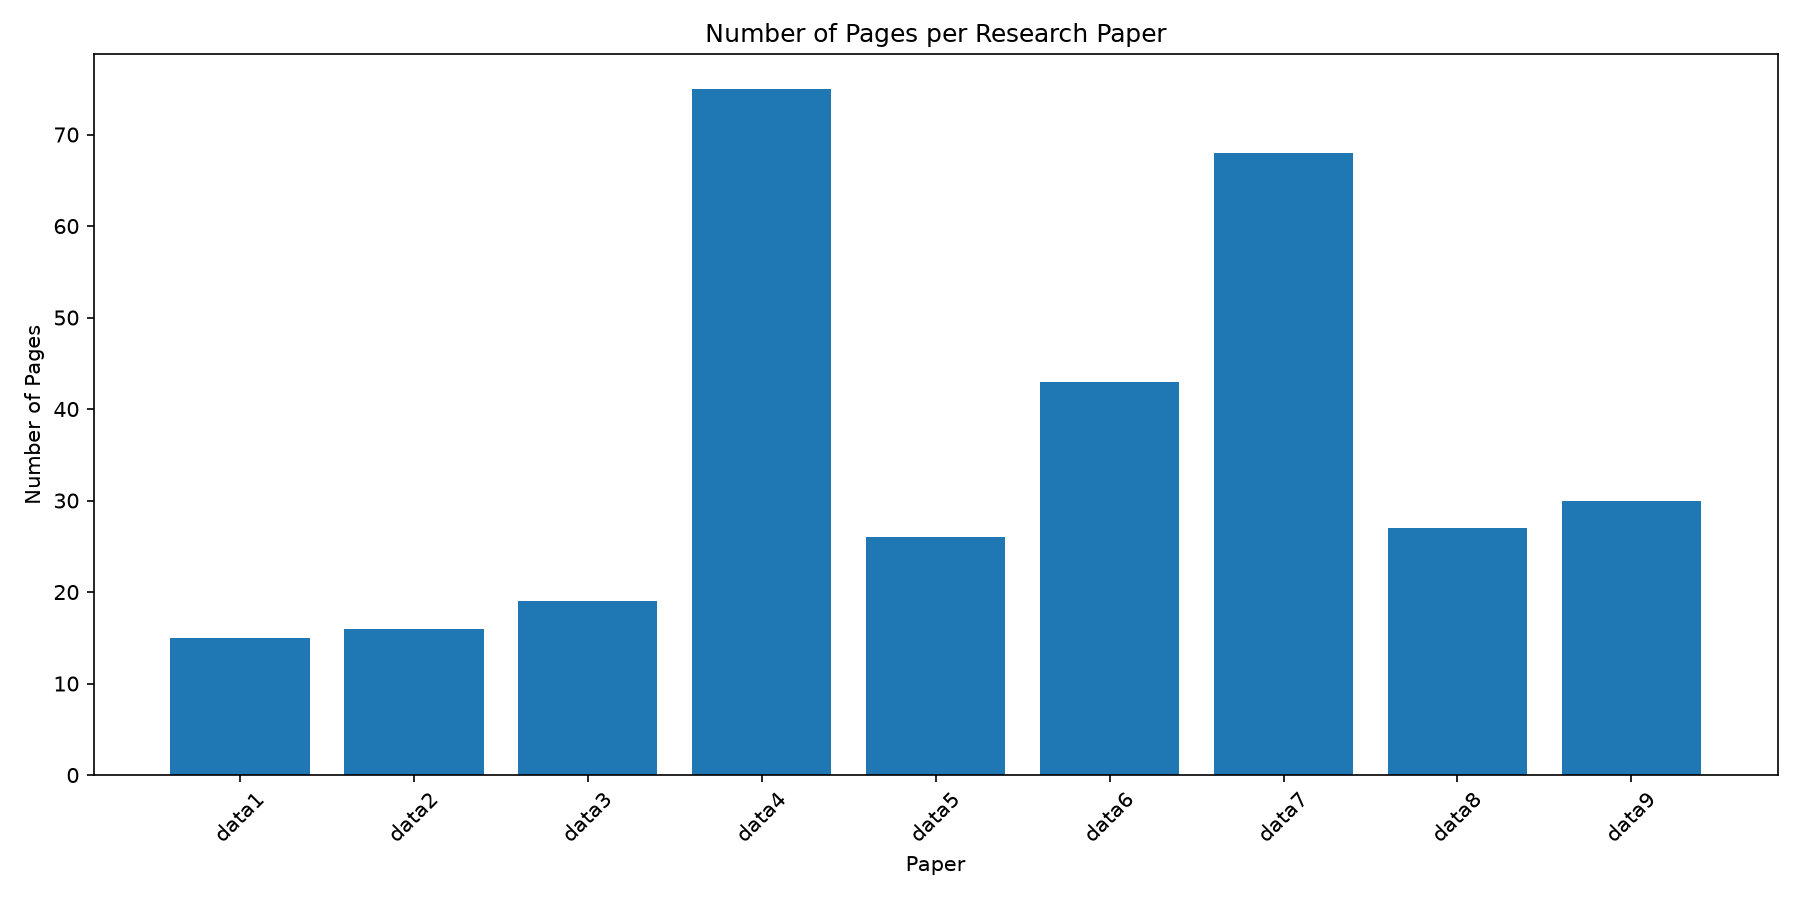

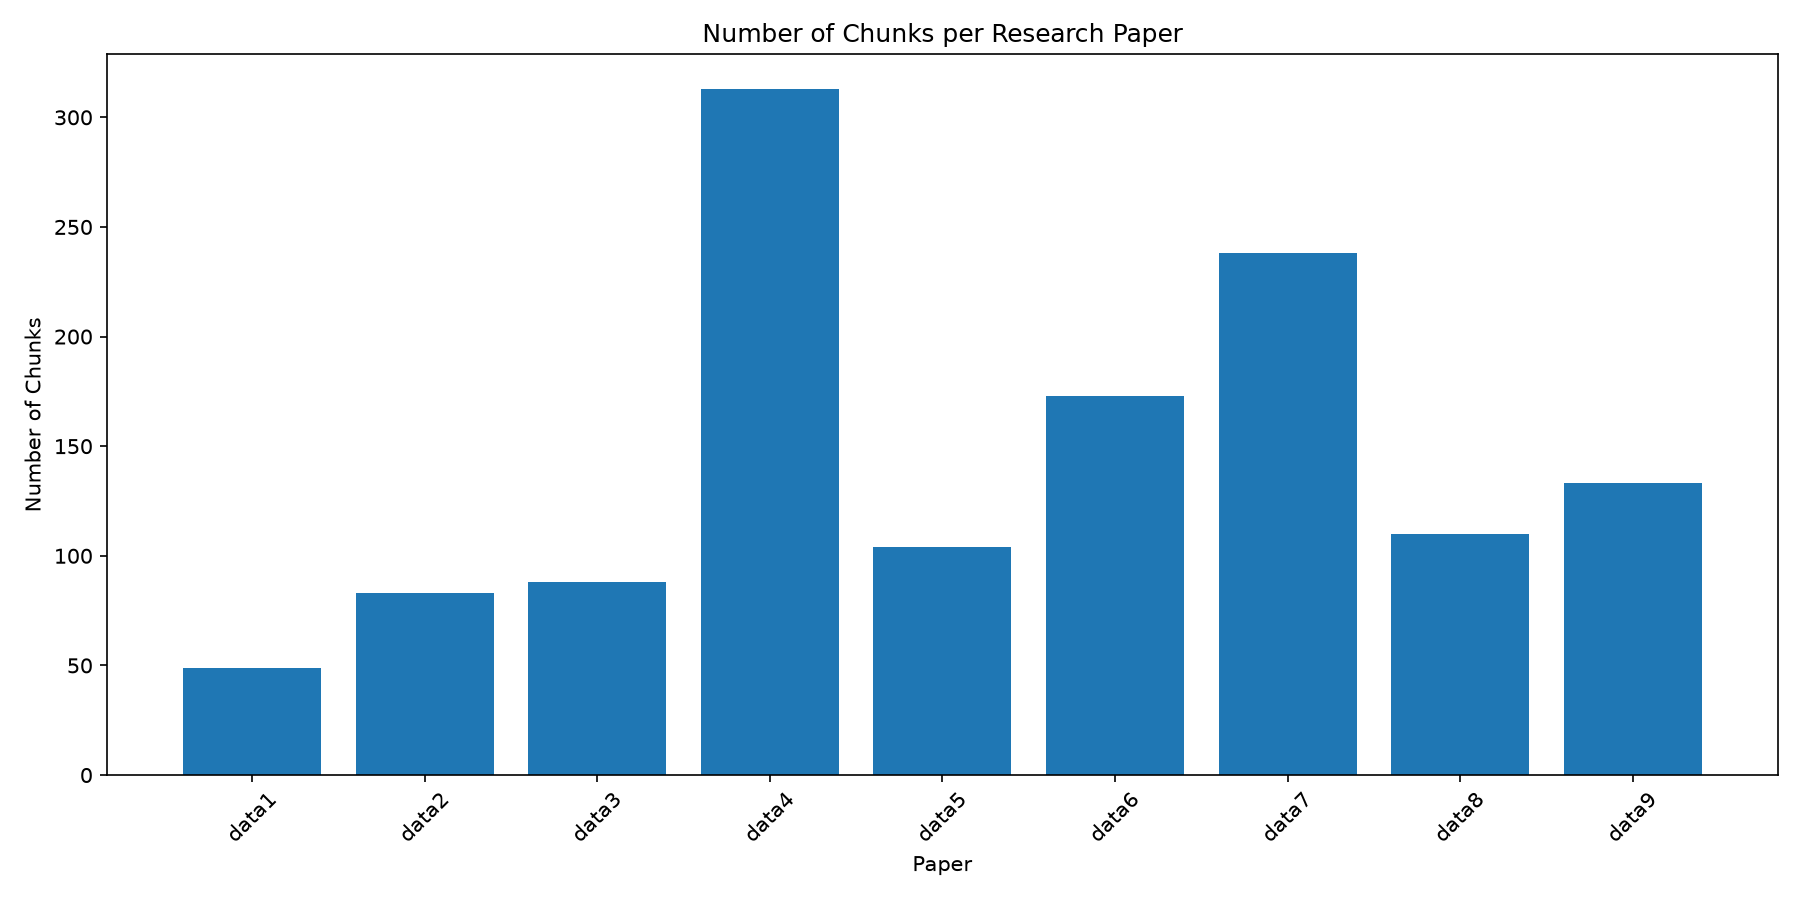

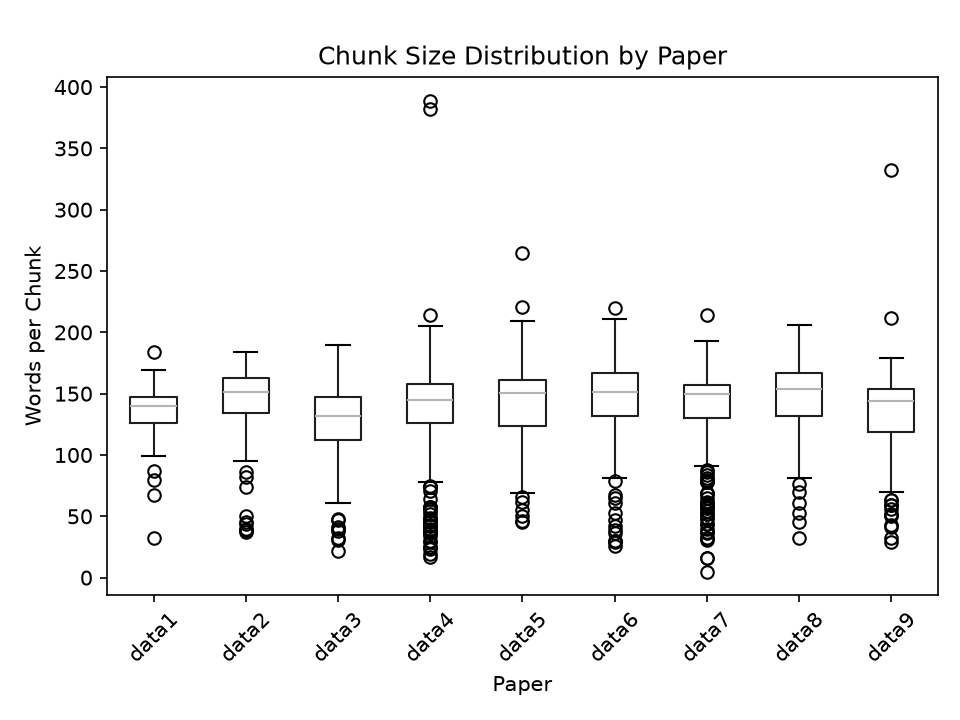

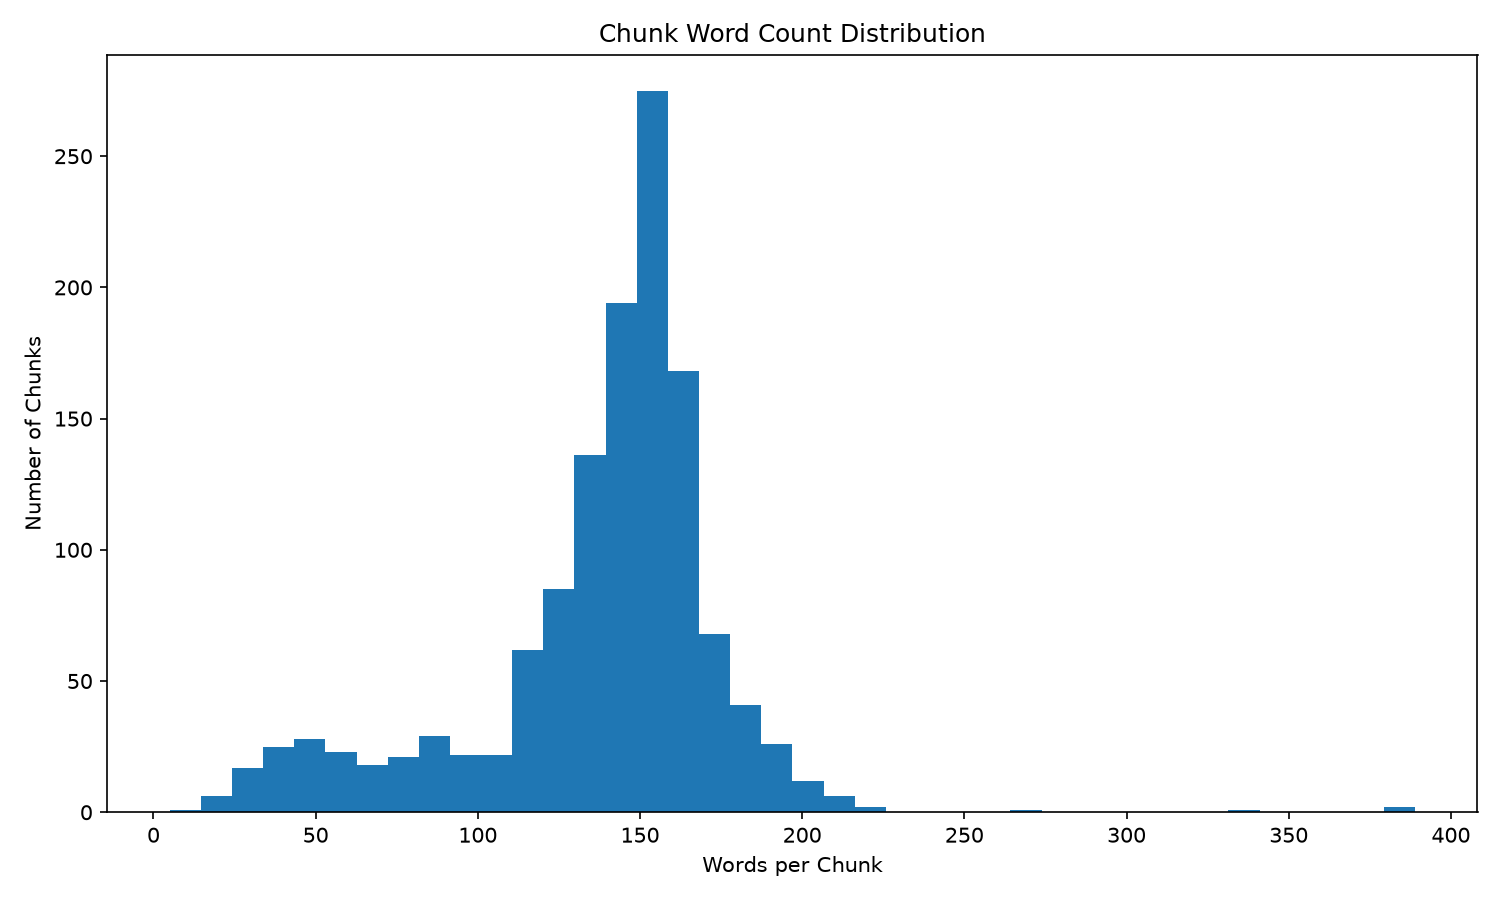

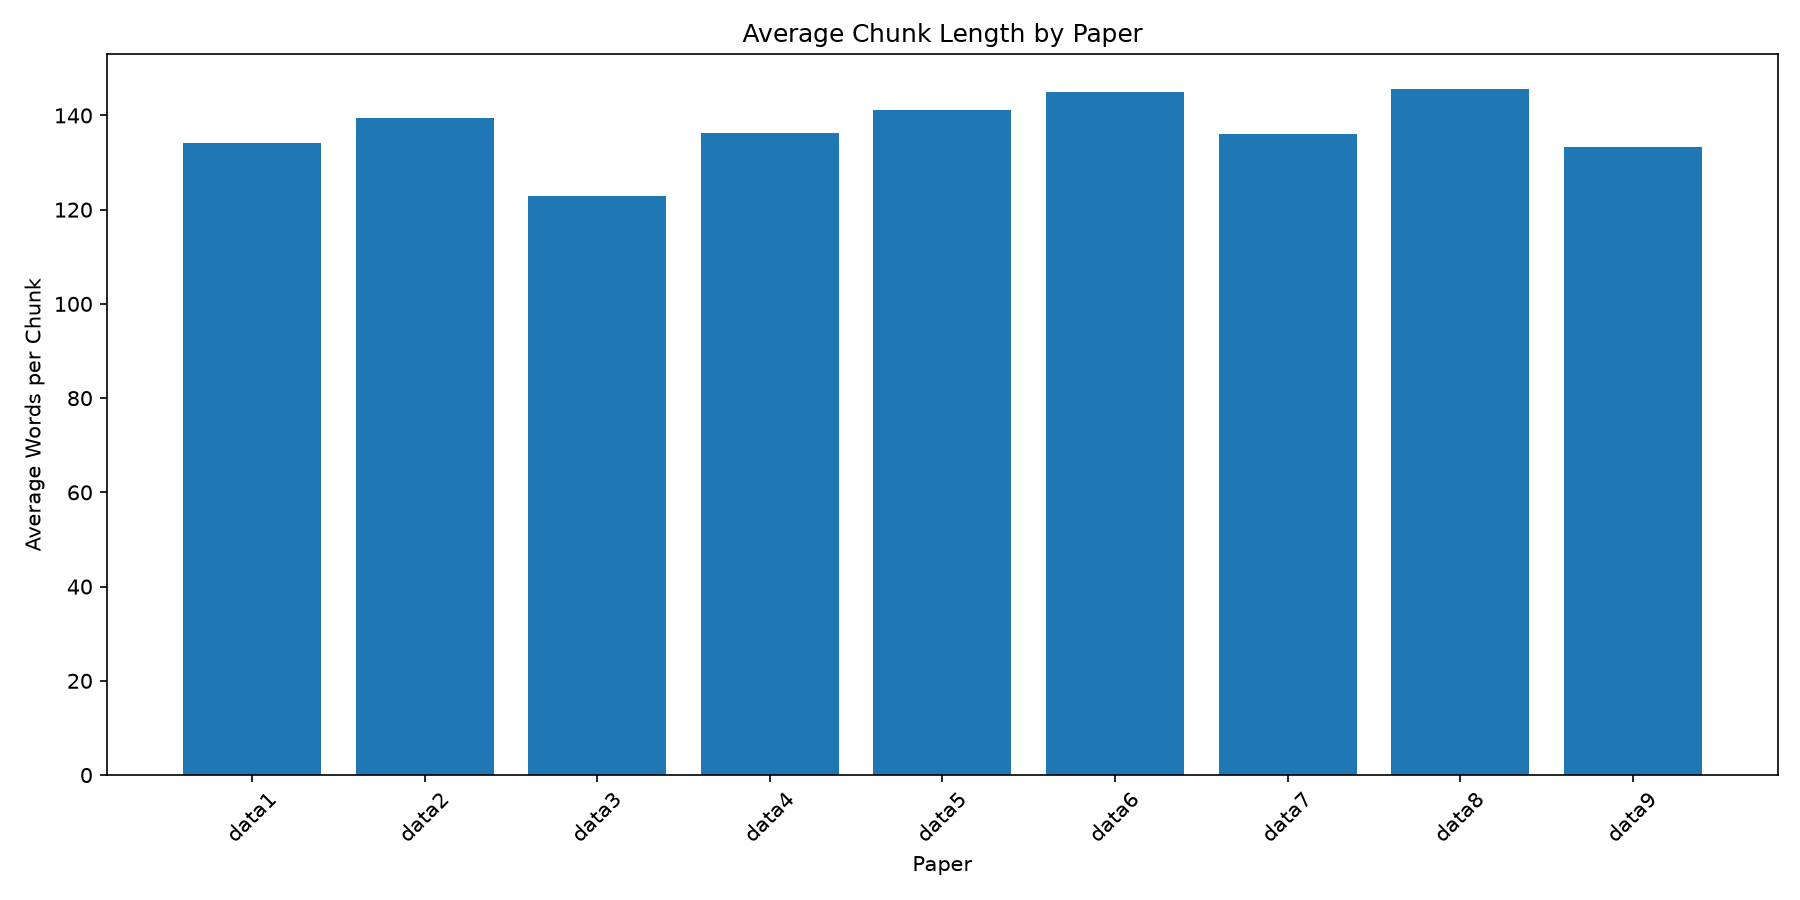

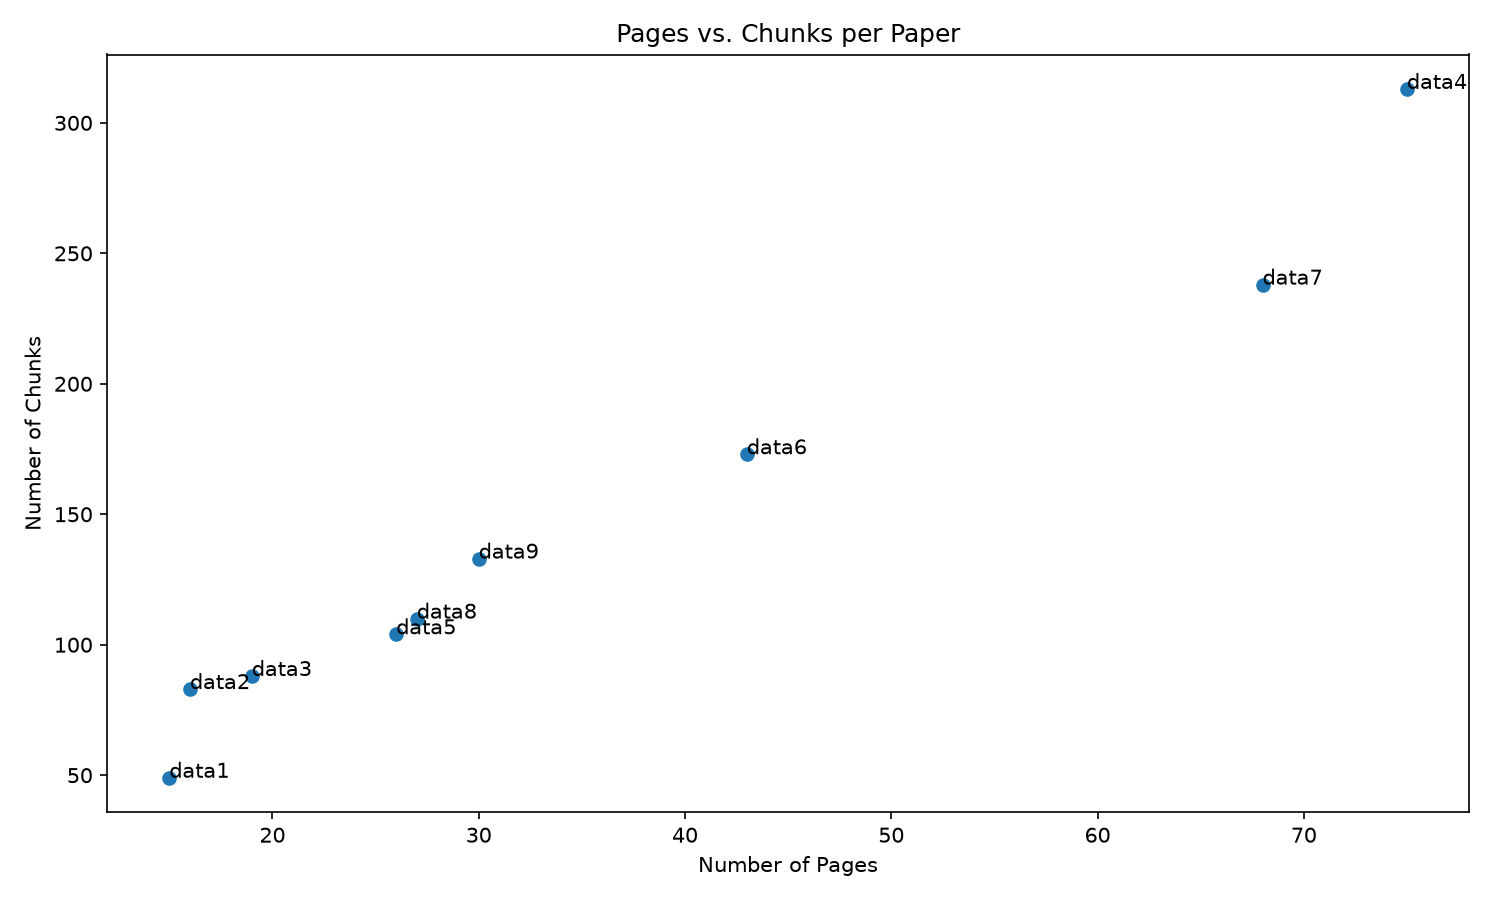

In [47]:
from IPython.display import Image, display

eda_dir = Path("outputs/eda")
for filename in [
    "pages_per_paper.png",
    "chunks_per_paper.png",
    "chunk_size_by_paper.png",
    "chunk_word_distribution.png",
    "average_chunk_length.png",
    "pages_vs_chunks.png",
]:
    image_path = eda_dir / filename
    if image_path.exists():
        display(Image(filename=str(image_path)))

## Launch The Demo

In [48]:
# Run from the project root in a terminal:
# !streamlit run app/app.py

# The app presents cited supporting passages with paper title, page number, and reranker score.

## Submission Checklist

- Editable source code is included above for every project module.
- Experiment outputs are loaded directly from the saved JSON artifacts.
- The Streamlit UI and stretch-goal modules are included.
- API keys are intentionally not embedded in this notebook.